# Data

In [1]:
!ls

am_download_data
am_runtime
am_runtime_nns
am_viewers
games-all.json
games_shooter
log.local.bin.old
log.local.logtime2.bin
log.txt.old
matrix_approx_zeshel.py
proof-of-concept.ipynb
proof-of-concept-open-data-round1.ipynb
proof-of-concept-open-data-round2.ipynb
proof-of-concept-round2-backup-1.ipynb
proof-of-concept-round2.ipynb
proof-of-concept-round3-backup1.ipynb
proof-of-concept-round3-backup2.ipynb
proof-of-concept-round3-backup3.ipynb
proof-of-concept-round3.ipynb
proof-of-concept-round3-parallel2.ipynb
proof-of-concept-round3-parallel.ipynb
proof-of-concept-round4.ipynb
proof-of-concept-round5.ipynb
proof-of-concept-round6.ipynb
pro_wrestling
__pycache__
req.json
shoot-prod.sh
shoot.sh
stand
star_trek
t.t
Untitled1.ipynb
Untitled.ipynb
yugioh


In [2]:
!ls yugioh

ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl


In [12]:
import pickle
import numpy as np
import os
import tqdm
import gc

from importlib import reload
from matplotlib import pyplot as plt

import matrix_approx_zeshel

matrix_approx_zeshel = reload(matrix_approx_zeshel)

!ls  | grep matrix_approx_zeshel

matrix_approx_zeshel.py


In [4]:
def load_ment_to_ent_scores(directory = "yugioh", shuffle_rows = 0):
    data = list()

    for file in os.listdir(directory):
        path = f"{directory}/{file}"
        print(f"Loading file {path}")
        with open(path, "rb") as f:
            data.append(
                pickle.load(f)
            )
    data = sorted(data, key = lambda x: x["arg_dict"]["n_ment_start"])

    for i in range(len(data) - 1):
        assert data[i]["arg_dict"]["n_ment_start"] + data[i]["arg_dict"]["n_ment"] == data[i + 1]["arg_dict"]["n_ment_start"]
        
    ment_to_ent_scores = list(map(lambda x: x["ment_to_ent_scores"], data))
    ment_to_ent_scores = np.vstack(ment_to_ent_scores)
    print("Loaded shape = ", ment_to_ent_scores.shape)
    
    if shuffle_rows:
        print(f"Shuffling... (seed = {shuffle_rows})")
        np.random.seed(shuffle_rows)
        np.random.shuffle(ment_to_ent_scores)
    
    return ment_to_ent_scores

In [5]:
class EvalContextRelevs:
    def __init__(self, relevs, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
        self.relevs = np.array(relevs)
        self.reqs_count = self.relevs.shape[0]
        self.games_count = self.relevs.shape[1]
        
        self.key_size = key_size
        self.key_games = (
            np.random.choice(np.arange(self.games_count), key_size, replace=False)
            if key_games is None else
            key_games
        )
        np.random.seed(seed)
        #np.random.shuffle(self.requests)

        self.try_det_attempts(det_attempts)
        self.train_split = int(self.reqs_count * train_size)

        assert key_size + 1 < self.train_split


        self.key_relevs = self.relevs[:key_size]
        self.train_relevs = self.relevs[key_size + 1: self.train_split]
        self.test_relevs = self.relevs[self.train_split:]

        self.slices = ["key", "train", "test"]
        print(len(self.key_relevs), len(self.train_relevs), len(self.test_relevs))

    def get_top_games(self):
        return self.relevs.mean(axis=0).argsort()[:100].numpy()

    def set_top_games_as_key(self):
        self.key_games = self.get_top_games()
        return self

    def try_det_attempts(self, det_attempts):
        def get_det(r):
            kr = r[:self.key_size, self.key_games] - r.mean()
            return np.abs(np.linalg.det(kr))

        best_i_array = np.arange(len(self.relevs))

        for i in range(det_attempts):

            r_i_array = np.arange(len(self.relevs))
            np.random.shuffle(r_i_array)

            n, o = get_det(self.relevs[r_i_array, :]), get_det(self.relevs[best_i_array, :])
            
            # print(f"try update key_reqs ({o} vs {n}...")
            if n > o:
                best_i_array = r_i_array
                print(f"updated det ({i}, {o} -> {n})")

        print("Best det = ", get_det(self.relevs[best_i_array, :]))

        self.relevs = self.relevs[best_i_array, :]
        print("Current de = ", get_det(self.relevs))
        
    def get_relevs(self, t = "train"):
        if t == "train":
            return self.train_relevs
        elif t == "key":
            return self.key_relevs
        elif t == "test":
            return self.test_relevs
        else:
            assert False
            
    def get_requests(self, t = "train"):
        if t == "train":
            return self.train_reqs
        elif t == "key":
            return self.key_reqs
        elif t == "test":
            return self.test_reqs
        else:
            assert False

In [6]:
ctx = EvalContextRelevs(load_ment_to_ent_scores("yugioh", shuffle_rows=42), det_attempts=100)

Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False.pkl
Loading file yugioh/ment_to_ent_scores_n_m_374_n_e_10031_all_layers_False3000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2500.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False1000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False2000.pkl
Loading file yugioh/ment_to_ent_scores_n_m_500_n_e_10031_all_layers_False500.pkl
Loaded shape =  (3374, 10031)
Shuffling... (seed = 42)
updated det (4, 6.137885635798218e+30 -> 2.524378507319208e+32)
updated det (8, 2.524378507319208e+32 -> 5.48097506735188e+34)
updated det (11, 5.48097506735188e+34 -> 4.6749692824069873e+36)
Best det =  4.6749693e+36
Current de =  4.6749693e+36
100 2260 1013


In [52]:
ctx.slices

['key', 'train', 'test']

In [7]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

### Меньше - лучше?

In [8]:
m = Popular(ctx)

In [9]:
m.fit()
m.get_score("test"), m.get_score("train")

np.mean(results), mse, len(results) =  0.09171767028627838 0.6754948 1013
np.mean(results), mse, len(results) =  0.0891637168141593 0.66850936 2260


(0.09171767028627838, 0.0891637168141593)

In [98]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "dssm_l2": 0,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_matrix": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
    "activation": "relu",
    "score_verbose": 0
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        self.fit_kwargs = fit_kwargs
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[i] for i in ctx.key_games])
                    for r_i in ctx.get_relevs(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[g_i] for r in ctx.get_relevs("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = ctx.get_relevs("key")
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        # return self.embed_users[t]
    
    def get_game_embs(self):
        return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
        #return self.embed_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.p = p
        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_matrix = p["train_matrix"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        train_user_scores = self.get_user_scores("train")
        train_user_embs = self.get_user_embs("train")
        game_embs = self.get_game_embs()
        
        initializer = tf.keras.initializers.GlorotUniform()
        values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        self.W = tf.Variable(values / 100., trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation=p["activation"]),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = game_embs[game_slice]
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = 0
                    
                    if self.train_matrix:
                        logits += train_user_embs_ @ self.W @ game_embs_.T

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores(
                        loss_batch = (1e9 if "loss_batch" not in p else p["loss_batch"]))
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_signed":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    sf = tf.nn.softmax(logits, axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        sf,
                        -sf
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_sum(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                elif self.loss == "KL100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    mask = np.argsort(-scores, axis=1) < 100
                    v = tf.keras.losses.KLDivergence()((scores.T >= qs.T).T, logits)
                else:
                    assert False
                    
                if self.p["c"]:
                    v += tf.reduce_mean(self.W * self.W) * p["c"]
                    
                if self.p["dssm_l2"]:
                    for weights_ in [self.u_dssm.weights, self.g_dssm.weights]:
                        for weight_ in weights_:
                            v += tf.reduce_sum(weight_ * weight_) * self.p["dssm_l2"]
                    
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            if self.train_matrix:
                weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
                
            opt.minimize(loss, weights)
            
            if p["score_verbose"] and (i % p["score_verbose"] == 0):
                print(f"\n=== Iteration {i} ===")
                for sl in self.ctx.slices:
                    print(f"slice = {sl}, score = {self.get_score(sl)}")
        print("last loss = ", loss())

    def recommend(self, t):
        logits = 0
                    
        if self.train_matrix:
            logits += self.get_user_embs(t) @ self.W @ self.get_game_embs().T

        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

In [46]:
np.argsort(np.array([
    [1, 2, 3],
    [10, 20, 30]
]), axis=1)

array([[0, 1, 2],
       [0, 1, 2]])

In [86]:
N = 3000

In [87]:
m = Popular(ctx)
m.fit()
m.get_score("train"), m.get_score("test")

np.mean(results), mse, len(results) =  0.0891637168141593 0.66850936 2260
np.mean(results), mse, len(results) =  0.09171767028627838 0.6754948 1013


(0.0891637168141593, 0.09171767028627838)

In [88]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004776812, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4885530973451327 2059.238 2260
np.mean(results), mse, len(results) =  0.43814412635735445 2036.0247 1013


(0.4885530973451327, 0.43814412635735445)

In [92]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 1e-6,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0045208386, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.48957079646017704 436.95013 2260
np.mean(results), mse, len(results) =  0.4415597235932872 426.82242 1013


(0.48957079646017704, 0.4415597235932872)

In [20]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 1e-6,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004799003, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5418318584070796 1170.2572 2260
np.mean(results), mse, len(results) =  0.46013820335636724 1184.37 1013


In [21]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 1e-6,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004804228, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5431725663716815 1526.7446 2260
np.mean(results), mse, len(results) =  0.4640868706811451 1530.9165 1013


In [23]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0.01,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 5e-5,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0042803977, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4630663716814159 4061.418 2260
np.mean(results), mse, len(results) =  0.4330700888450148 4060.1838 1013


In [28]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0055245575, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5370530973451327 6113.3535 2260
np.mean(results), mse, len(results) =  0.46474827245804545 6130.059 1013


In [29]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'softmax',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)


KeyboardInterrupt: 

In [30]:
N = 300
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'mse',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(0.42000526, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.2843141592920354 0.40405124 2260
np.mean(results), mse, len(results) =  0.2780059230009872 0.4335728 1013


In [36]:
N = 3000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'qmse',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(0.2602769, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4045132743362832 73.71154 2260
np.mean(results), mse, len(results) =  0.3926456071076012 73.822525 1013


In [37]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'qmse',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(0.19489093, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.46565044247787607 73.38542 2260
np.mean(results), mse, len(results) =  0.43792694965449164 73.50988 1013


In [76]:
N = 1000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': True, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1025
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[-4.18947486e-04, -1.11743066e-04, -1.30490866e-03, ...,
        -5.65114315e-04, -3.97412776e-04,  1.46466191e-04],
       [ 1.54441269e-03, -3.94551462e-04,  1.03732792e-03, ...,
        -1.04388295e-04,  4.53324174e-04,  1.12674828e-03],
       [ 6.67617889e-04,  1.42783159e-03,  1.47244777e-03, ...,
         1.31702097e-03,  9.50877089e-04,  4.11952438e-04],
       ...,
       [-1.25302380e-04, -5.54113103e-05,  1.00899395e-03, ...,
         2.07951962e-04,  3.59841593e-04,  5.67199277e-05],
       [ 6.12860778e-04, -2.41337562e-04,  4.29733394e-04, ...,
         8.64562389e-05,  3.91197507e-04, -1.72384945e-03],
       [-4.87292040e-04,  1.07646966e-03, -6.7489

-0.00065956847
-0.0009027626
-0.001092718
-0.0008583745
-0.00057162624
-0.00045599794
-0.0006306778
-0.00026100283
-0.00039873694
-0.00086479733
-0.00097563583
-0.00033511853
-0.00055200676
-0.00065291685
-0.0003983624
-0.00085136015
-0.0005477459
-0.000954375
-0.00055569893
-0.00056930067
0.0001894172
-0.0008024885
-0.00023576923
0.0007860289
-0.0008766693
-0.00062581693
0.0005230626
0.0004423327
-0.000876278
-0.0002495427
-0.00075897493
-0.00013268641
0.000113394315
-0.0008671998
4.5429566e-05
-0.00073361123
-0.00093999953
-0.00028869873
-0.00090984773
-0.0004764035
-0.00058265094
-0.0010606144
-0.0007399576
-0.00082753174
0.00015286912
-0.00030271558
-0.0011369648
-0.00064026663
-0.00085913547
-0.00029380494
-0.0007241669
-0.0010761926
0.00014661078
-0.0011125439
-0.00049124623
-0.00056642323
-0.00082746975
-4.411654e-05
-0.0006194443
0.0001094346
-0.0005675118
-0.0003798148
-0.00017863604
-0.0005684638
-0.00049487763
-0.0005687279
-0.00044777832
0.00011211676
-3.4442128e-05
-0.0008

In [80]:
N = 1000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': True, 'loss': 'softmax_signed',
    'loss_batch': 1024, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1025
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[-8.6535106e-04, -1.7039456e-03,  8.2113413e-04, ...,
         5.2087381e-04,  4.9560232e-04, -1.6195558e-03],
       [ 5.8304681e-04, -6.4460335e-05, -1.4875813e-03, ...,
        -1.1503468e-03, -6.3286588e-04, -1.2851442e-03],
       [-7.9507532e-05, -1.5396837e-03,  6.2818913e-04, ...,
        -1.5403518e-03,  1.4079047e-03, -1.0246601e-03],
       ...,
       [-1.1161548e-03,  3.0297547e-04, -1.2180423e-03, ...,
         5.1273213e-04,  1.4650867e-04,  1.4351171e-03],
       [ 1.4310890e-03,  1.4670244e-03, -1.0812165e-03, ...,
        -1.5430149e-03, -1.6419371e-03,  1.3797274e-03],
       [ 1.2907904e-03, -8.1991672e-04, -1.3254770e-03, ...,
         1.5902752

-0.0004642974
-0.00046492
-0.0005141192
-0.0004414646
-0.00049674104
-0.00049180625
-0.00051767565
-0.00047961905
-0.00048244934
-0.00049615855
-0.00049742305
-0.0004954321
-0.0005112842
-0.0004933682
-0.0004648752
-0.00048687056
-0.00048653103
-0.0004448197
-0.00042614396
-0.0005402008
-0.00050579925
-0.00047493182
-0.0005479344
-0.0004586234
-0.0004861388
-0.00047019904
-0.00049309025
-0.0005619931
-0.00047887754
-0.00045474689
-0.0004786195
-0.00048663726
-0.00046842004
-0.0005036996
-0.00045443594
-0.00049027795
-0.00048235417
-0.0005178655
-0.0004918617
-0.0004977702
-0.00051669567
-0.00045585554
-0.00048446318
-0.0004880094
-0.0005329364
-0.00046817746
-0.0005054674
-0.0005171215
-0.00048030194
-0.0004887203
-0.00049600704
-0.0005361496
-0.0005642712
-0.0005325451
-0.00042308168
-0.00046781867
-0.000499165
-0.0005004107
-0.00048251712
-0.00047404296
-0.0004929132
-0.0004972873
-0.00046149222
-0.00050854107
-0.00046917374
-0.0005651754
-0.0005457666
-0.0005233983
-0.00053472305
-0

In [85]:
N = 1000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': True, 'loss': 'softmax',
    'loss_batch': 5000, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 16
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[ 1.3456423e-03, -1.2261366e-03,  1.5377748e-03, ...,
        -5.8862268e-05,  3.6712975e-04, -1.1940848e-03],
       [-1.5530031e-03, -1.6005224e-03,  1.3768927e-03, ...,
        -1.4843763e-04, -1.5030151e-03, -3.3530311e-04],
       [-1.1270716e-03,  4.5279771e-04, -1.1966666e-03, ...,
         1.6247315e-03, -1.5807514e-03, -4.9780308e-05],
       ...,
       [ 3.3136920e-04,  3.1319438e-04,  2.7731611e-04, ...,
         2.4391770e-04,  1.2376523e-03,  4.1158288e-04],
       [ 6.6360907e-04, -6.2587333e-04,  1.5635767e-03, ...,
        -1.3671452e-03,  5.7660264e-04, -1.3335601e-03],
       [ 1.4817971e-03,  4.6493561e-04,  8.9454977e-04, ...,
        -1.4216108

-0.00013632872
-9.999788e-05
-8.730513e-05
-6.249997e-05
-8.346996e-05
-6.111057e-05
-9.8181095e-05
-7.4687014e-05
-0.00010934853
-7.817901e-05
-0.00013715801
-9.026494e-05
-0.00012440447
-9.99843e-05
-0.000111383306
-7.574761e-05
-7.50886e-05
-7.597893e-05
-8.6242166e-05
-0.00010005409
-9.803152e-05
-8.8849876e-05
-9.988359e-05
-8.173002e-05
-8.255816e-05
-0.00012661089
-0.00012397162
-9.999915e-05
-7.4793075e-05
-8.830754e-05
-9.5320946e-05
-4.9998496e-05
-0.00011249913
-7.4999836e-05
-0.00010182404
-8.718109e-05
-4.5622302e-05
-0.000110566165
-9.1670125e-05
-6.2483e-05
-5.289287e-05
-8.58708e-05
-0.00012238149
-5.1495408e-05
-0.00011710003
-3.8019745e-05
-3.8014234e-05
-9.427247e-05
-9.241876e-05
-7.3140895e-05
-6.439904e-05
-6.262122e-05
-7.50001e-05
-5.6039495e-05
-6.403635e-05
-8.720804e-05
-2.5103984e-05
-5.927256e-05
-0.00010269613
-7.397038e-05
-9.990272e-05
-9.9560835e-05
-5.3832977e-05
-0.00010020766
-7.74275e-05
-9.054347e-05
-8.755374e-05
-7.43279e-05
-0.0001003348
-0.0001

In [88]:
N = 2000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': True, 'loss': 'softmax',
    'loss_batch': 5000, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 32
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[-1.7260745e-03,  8.3473953e-04, -5.3747892e-05, ...,
         1.4107868e-03, -3.0555145e-04, -9.9818315e-04],
       [ 1.2859014e-03, -1.2845278e-03,  1.0677374e-03, ...,
         6.7172112e-04,  1.2064219e-03,  7.9625932e-04],
       [ 3.4536122e-05,  1.2366164e-03, -2.6815891e-04, ...,
        -9.0912695e-04,  8.3673297e-04,  5.0828664e-04],
       ...,
       [-1.1364820e-03,  1.5671334e-03, -1.5009730e-03, ...,
         6.6658837e-04,  1.1696726e-03,  1.6142884e-03],
       [-1.0005168e-03, -1.9838974e-04, -1.2162171e-03, ...,
         5.9222919e-04, -6.8672322e-04, -9.7263663e-04],
       [ 2.1022857e-04, -1.2774485e-03,  3.0191586e-04, ...,
         6.1080756

-0.00011081368
-0.0001068932
-7.732771e-05
-8.331126e-05
-0.00010861003
-8.1111095e-05
-9.899743e-05
-0.0001057015
-8.7388806e-05
-8.911579e-05
-9.3930495e-05
-8.026411e-05
-9.884657e-05
-9.882369e-05
-0.00010610878
-0.00010985781
-6.8736306e-05
-0.00010401608
-7.475363e-05
-0.00013029434
-0.00014293347
-8.273868e-05
-7.6167715e-05
-0.00011011672
-9.393724e-05
-6.708827e-05
-0.00014007994
-0.00012135313
-0.00011143155
-0.00011161878
-7.7120145e-05
-9.7323624e-05
-0.000102501916
-7.184967e-05
-8.579966e-05
-0.000109603265
-9.0328096e-05
-8.907187e-05
-9.095451e-05
-0.00011652112
-0.00010741006
-9.771119e-05
-0.00013134144
-7.375051e-05
-9.4004965e-05
-0.00011359136
-6.300304e-05
-0.00011168682
-0.00013026118
-0.00012831563
-0.00013794226
-0.00012665674
-0.00012998484
-9.924419e-05
-9.676293e-05
-0.000116779986
-9.471694e-05
-0.000114716444
-0.0001403339
-0.0001299042
-0.00010500785
-0.0001081806
-0.00012848258
-0.000106359126
-0.00012731717
-7.627636e-05
-0.00010605987
-0.00010547361
-9

-0.00011280181
-8.570868e-05
-8.7291024e-05
-0.00011174686
-9.3787814e-05
-0.0001021003
-0.00011272538
-0.00010459654
-0.00011384482
-0.00012506123
-0.00010001117
-0.00012285866
-0.00012504435
-0.00013071651
-0.00012306846
-0.00015590481
-9.521481e-05
-6.8777146e-05
-0.000115448354
-0.00011874914
-0.00012538115
-0.00016221523
-0.00012543086
-0.00011877477
-0.00010915668
-9.4481045e-05
-0.0001093937
-0.00010921597
-0.0001070615
-9.3625924e-05
-9.732401e-05
-0.00012126636
-0.00011747661
-0.000110426925
-7.923001e-05
-0.00013817975
-0.00012906331
-0.00013487539
-0.000107242966
-0.00013690996
-0.00010531948
-0.0001191953
-0.00012991815
-0.00010555096
-9.860546e-05
-0.00011228788
-0.00016120814
-0.00014171498
-0.00012045282
-0.00015783639
-0.00012492244
-8.802385e-05
-0.00012560161
-8.975705e-05
-9.9978555e-05
-0.000100184705
-0.00012048873
-0.00011365674
-0.00013022564
-0.0001293304
-0.00011250322
-9.787631e-05
-0.000119737124
-0.00011252802
-0.00013391401
-0.0001113363
-0.00013165482
-0.0

-7.752159e-05
-9.048528e-05
-0.00010624526
-0.00011254085
-9.567671e-05
-8.12707e-05
-0.0001380765
-0.00010408237
-0.0001096073
-7.5033575e-05
-0.00010117142
-0.000111474204
-0.00011250124
-0.00010863339
-0.00011610167
-0.0001235975
-0.00012513842
-0.000113455484
-0.00011876707
-8.91185e-05
-0.00011331501
-8.1475795e-05
-0.00010616736
-0.00012348266
-9.086889e-05
-9.453285e-05
-0.00012442486
-0.00012765288
-0.00012999252
-0.00012034301
-0.00010049348
-0.00012521603
-0.00012012217
-0.0001439715
-0.0001066906
-0.00011019491
-0.000114922026
-0.00010102651
-0.00013143395
-0.0001318457
-8.522065e-05
-0.000113138376
-5.6274337e-05
-0.00012980247
-0.00012017126
-0.000100000456
-0.000114018156
-0.00010625043
-8.299321e-05
-0.0001249503
-0.00010435317
-0.00010463686
-0.00010625515
-9.324148e-05
-0.00011726071
-0.00011962841
-9.74756e-05
-0.00013739873
-8.7832545e-05
-0.00010216483
-0.00010936614
-7.920357e-05
-0.00010713706
-8.138192e-05
-0.000118181895
-9.402197e-05
-0.00012828075
-0.000117018

In [89]:
N = 2000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': True, 'loss': 'softmax',
    'loss_batch': 5000, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 64
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[ 8.1381085e-04, -8.2344911e-04,  1.4852711e-03, ...,
         6.8206759e-04, -1.3330613e-03, -1.9581243e-04],
       [-3.7733167e-05, -3.1099215e-04,  1.6856998e-04, ...,
         1.9904882e-04,  1.2377921e-03,  6.1922777e-04],
       [ 3.2445789e-06,  1.2639436e-03,  1.7161316e-03, ...,
        -7.8991731e-04, -2.1206379e-04,  1.1088133e-03],
       ...,
       [-9.3688769e-04,  7.3202996e-04, -7.9831632e-05, ...,
         1.4937914e-03, -9.8467420e-04,  9.8321412e-04],
       [-1.5063488e-03, -1.3958223e-03, -7.8154885e-04, ...,
         1.4190149e-03,  1.6549886e-04, -7.6670764e-04],
       [ 1.4055499e-03, -8.5168972e-04,  1.0590485e-03, ...,
        -8.7308564

-0.00014041435
-9.131816e-05
-0.00013040048
-0.00014646913
-0.000101955506
-0.000110511945
-0.0001221169
-0.000112836526
-8.839831e-05
-0.000120968805
-8.853482e-05
-0.00013628883
-0.00013377686
-0.00011994817
-0.00011569867
-0.00012520848
-0.00013013357
-0.00011729147
-0.00014360368
-0.00014159137
-0.00012312761
-0.00012678809
-0.00010755663
-9.789836e-05
-0.00012937079
-0.00013700157
-0.000110776375
-0.00012645026
-0.00012203166
-0.00013960605
-9.71644e-05
-0.00012336219
-0.000118869066
-0.00011897089
-0.00012490606
-0.00013417906
-0.00010006425
-0.00011749822
-9.358355e-05
-0.0001150022
-0.00013040699
-0.00011111611
-0.0001530491
-0.00014162825
-0.00012678244
-0.00012294274
-0.0001289755
-0.00012627161
-0.000121203
-0.0001352778
-0.000118815544
-0.00012555318
-0.00014316196
-0.00011320302
-0.0001393995
-0.00012480046
-0.0001445835
-0.00011843662
-0.00013247022
-0.0001314728
-0.00011428065
-0.0001310159
-0.00013810578
-0.00014627125
-0.00013730151
-0.00014303497
-0.00012633366
-0.000

-0.00012393571
-0.00013124099
-0.00013711624
-0.00014619091
-0.00012874257
-0.00015518749
-0.00014725458
-0.00011486981
-0.00014274965
-0.00012301581
-0.000121152414
-0.00012939218
-0.00014719235
-0.00013703665
-0.00012566026
-0.00015458331
-0.00012236973
-0.00012991071
-0.00012699282
-0.00015715438
-0.00012161449
-0.0001407495
-0.00012789032
-0.00014081098
-0.00014910594
-0.00013417688
-0.00013603304
-0.00013521287
-0.00015952409
-0.00012947827
-0.00013895279
-0.00014773542
-0.000111810914
-0.00015394345
-0.00014078474
-0.00013002123
-0.00014637609
-0.00014075436
-0.000112678266
-0.0001284672
-0.00013218829
-0.00014456414
-0.000149165
-0.00012810412
-0.000115830895
-0.00013724802
-0.000119772434
-0.0001349996
-0.00013293202
-0.0001419102
-0.00012943191
-0.00012542472
-0.00013860349
-0.00012850831
-0.00015040503
-0.00014548431
-0.00012972954
-0.00014825106
-0.00013077894
-0.000122051846
-0.00013742289
-0.00014763477
-0.00011558943
-0.00014244889
-0.0001538641
-0.0001390108
-0.000148142

-0.0001300594
-0.00014641583
-0.00015590007
-0.00014970475
-0.00013839157
-0.00014150821
-0.00015490878
-0.00014857033
-0.0001539834
-0.00015652085
-0.00014655347
-0.00014315799
-0.00015492996
-0.00013930202
-0.0001282928
-0.00014113383
-0.00015459303
-0.00014782528
-0.00012630055
-0.00013890881
-0.00015769208
-0.0001235902
-0.00015833443
-0.000163958
-0.00013858173
-0.00013633717
-0.00016201736
-0.00015370731
-0.00016962767
-0.00012571378
-0.00017285538
-0.00014066826
-0.00015169871
-0.00016221318
-0.00013134585
-0.00013526094
-0.00014700333
-0.00015629864
-0.00013781911
-0.00013883633
-0.00012511072
-0.00013286258
-0.00013405283
-0.00013600709
-0.0001423234
-0.00014093977
-0.00013506634
-0.00013955048
-0.00013595412
-0.0001558718
-0.00013576128
-0.00016375637
-0.0001459018
-0.00015241919
-0.00012760265
-0.00014144785
-0.00013889316
-0.00015292277
-0.00014494976
-0.00013646205
-0.0001427815
-0.0001430963
-0.00014615148
-0.00014888866
-0.00014185613
-0.00015285317
-0.00016110741
-0.000

In [90]:
N = 2000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 5000, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[ 1.3696677e-03,  1.0055250e-03,  3.7176476e-04, ...,
         2.0495028e-04, -6.7208032e-04, -1.3342324e-03],
       [-1.4029809e-03,  4.1923777e-04,  8.8983921e-05, ...,
         3.3190696e-05,  2.7049586e-04,  5.8390526e-04],
       [-1.3872939e-03,  1.1452180e-03,  6.4188929e-04, ...,
         1.4005185e-03, -1.2538416e-03, -1.6134992e-04],
       ...,
       [ 1.5119377e-03,  5.2018912e-04, -1.4626952e-03, ...,
         9.5561711e-04, -5.6914141e-04,  4.4065638e-04],
       [ 3.5318761e-04, -1.6442297e-03,  2.3637310e-04, ...,
        -1.0082270e-03,  1.0144749e-03,  6.3962594e-04],
       [ 2.2516921e-04,  1.3658857e-03, -5.2914157e-04, ...,
        -1.6357314

-0.00017442324
-0.00016383384
-0.00016398673
-0.00017070855
-0.00016803574
-0.0001583879
-0.0001732279
-0.00016548196
-0.00016585428
-0.00016679853
-0.00016516398
-0.0001642647
-0.00016523279
-0.0001717275
-0.00017504682
-0.00017147673
-0.00016760653
-0.00017073171
-0.00017413456
-0.00017221972
-0.0001720545
-0.00016272854
-0.00016634517
-0.00016375529
-0.00016305794
-0.00017189572
-0.00016488695
-0.00016916679
-0.0001732223
-0.00017229587
-0.00016799782
-0.00017141504
-0.00016968635
-0.00016931702
-0.00016340984
-0.00017065472
-0.00016231225
-0.0001660792
-0.00016670798
-0.00016782814
-0.00017302646
-0.0001660812
-0.00016393977
-0.00016294801
-0.00017480394
-0.00016974217
-0.00017175145
-0.00017567191
-0.00017470145
-0.0001679138
-0.0001737988
-0.00017368246
-0.00016823935
-0.0001692787
-0.00017180653
-0.00016615861
-0.00016761935
-0.00017079295
-0.00016594924
-0.00017018299
-0.00017148329
-0.00016839408
-0.00017524985
-0.00016998094
-0.00018160683
-0.00017229705
-0.00016948528
-0.000

-0.00017794513
-0.00017687782
-0.00018061524
-0.00018149712
-0.00017372487
-0.0001823578
-0.00018546192
-0.00017811038
-0.00017994564
-0.00017732508
-0.00017719783
-0.00018396918
-0.00017784144
-0.00017791631
-0.00017627403
-0.00017925189
-0.00017773324
-0.00017932753
-0.000178695
-0.00018455392
-0.00017700694
-0.00017688697
-0.00018176448
-0.00017973004
-0.00017840281
-0.00017988251
-0.00017727059
-0.00017975553
-0.0001792645
-0.00017990584
-0.0001781333
-0.0001787413
-0.00017924732
-0.00018257668
-0.00018291017
-0.00018102712
-0.00018073451
-0.00017680122
-0.00018416907
-0.0001779346
-0.00018217952
-0.00017479622
-0.00018610332
-0.0001789715
-0.00018028589
-0.00018339208
-0.00017428571
-0.00018306947
-0.00018123478
-0.00018444589
-0.00018133565
-0.0001813562
-0.00018410859
-0.00017667231
-0.00017605769
-0.00018230117
-0.00018607872
-0.00017461713
-0.00017759761
-0.0001806259
-0.00018272064
-0.0001779053
-0.00017720851
-0.00018635078
-0.0001797028
-0.0001770667
-0.00018229448
-0.00018

-0.0001857954
-0.00018598729
-0.00018154473
-0.00018690605
-0.0001859656
-0.00018632603
-0.00018237201
-0.00018345521
-0.00018267384
-0.0001857977
-0.0001832521
-0.00018714266
-0.00018206128
-0.00018443968
-0.0001814888
-0.00018863959
-0.00018649492
-0.00018357503
-0.00018948238
-0.00018372569
-0.00018148133
-0.00018410676
-0.00018785812
-0.00018381696
-0.0001831181
-0.00018911668
-0.00018749382
-0.00018625625
-0.00018351995
-0.00018675913
-0.00018504195
-0.00018900767
-0.0001821879
-0.00018367668
-0.00018251367
-0.00018134214
-0.00018294211
-0.00018268458
-0.00018327923
-0.00018326285
-0.00018535883
-0.00018135035
-0.00018244356
-0.00018542245
-0.00018803621
-0.00018674582
-0.00018631162
-0.00018557356
-0.00018479092
-0.00018310019
-0.00017693083
-0.00018636526
-0.00018678978
-0.00018514523
-0.00018506694
-0.00018334553
-0.0001879182
-0.00018079899
-0.00018685861
-0.00018591584
-0.00018599234
-0.00018448744
-0.0001874889
-0.00018112976
-0.00018455082
-0.00018698338
-0.00018869438
-0.0

In [99]:
N = 10000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 5000, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 1000,
    'score_verbose': 100
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.03520000000000001 106.394966 100
slice = key, score = 0.03520000000000001
np.mean(results), mse, len(results) =  0.02930973451327434 104.28012 2260
slice = train, score = 0.02930973451327434
np.mean(results), mse, len(results) =  0.03076999012833169 103.66565 1013
slice = test, score = 0.03076999012833169

=== Iteration 100 ===
np.mean(results), mse, len(results) =  0.3071 225.04195 100
slice = key, score = 0.3071
np.mean(results), mse, len(results) =  0.25619469026548675 203.4674 2260
slice = train, score = 0.25619469026548675
np.mean(results), mse, len(results) =  0.2503060217176703 202.92233 1013
slice = test, score = 0.2503060217176703

=== Iteration 200 ===
np.mean(results), mse, 

np.mean(results), mse, len(results) =  0.3827433628318584 723.68097 2260
slice = train, score = 0.3827433628318584
np.mean(results), mse, len(results) =  0.3584402764067128 718.63727 1013
slice = test, score = 0.3584402764067128

=== Iteration 2300 ===
np.mean(results), mse, len(results) =  0.46149999999999997 745.7695 100
slice = key, score = 0.46149999999999997
np.mean(results), mse, len(results) =  0.3809513274336283 746.99146 2260
slice = train, score = 0.3809513274336283
np.mean(results), mse, len(results) =  0.35655478775913135 741.22064 1013
slice = test, score = 0.35655478775913135

=== Iteration 2400 ===
np.mean(results), mse, len(results) =  0.4599999999999999 791.53973 100
slice = key, score = 0.4599999999999999
np.mean(results), mse, len(results) =  0.38346460176991154 786.9745 2260
slice = train, score = 0.38346460176991154
np.mean(results), mse, len(results) =  0.3586574531095756 777.9381 1013
slice = test, score = 0.3586574531095756

=== Iteration 2500 ===
np.mean(result

np.mean(results), mse, len(results) =  0.39417699115044247 1636.0337 2260
slice = train, score = 0.39417699115044247
np.mean(results), mse, len(results) =  0.36655478775913136 1617.7047 1013
slice = test, score = 0.36655478775913136

=== Iteration 4600 ===
np.mean(results), mse, len(results) =  0.4646999999999999 1739.5085 100
slice = key, score = 0.4646999999999999
np.mean(results), mse, len(results) =  0.392 1723.234 2260
slice = train, score = 0.392
np.mean(results), mse, len(results) =  0.36440276406712735 1706.6238 1013
slice = test, score = 0.36440276406712735

=== Iteration 4700 ===
np.mean(results), mse, len(results) =  0.46440000000000003 1695.0186 100
slice = key, score = 0.46440000000000003
np.mean(results), mse, len(results) =  0.39319911504424776 1696.9622 2260
slice = train, score = 0.39319911504424776
np.mean(results), mse, len(results) =  0.36454096742349457 1685.5598 1013
slice = test, score = 0.36454096742349457

=== Iteration 4800 ===
np.mean(results), mse, len(resul

KeyboardInterrupt: 

In [102]:
N = 10000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 1000, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 1000,
    'score_verbose': 250
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0417 37.25347 100
slice = key, score = 0.0417
np.mean(results), mse, len(results) =  0.0317787610619469 36.75345 2260
slice = train, score = 0.0317787610619469
np.mean(results), mse, len(results) =  0.028963474827245806 37.7345 1013
slice = test, score = 0.028963474827245806

=== Iteration 250 ===
np.mean(results), mse, len(results) =  0.4697999999999999 210.88841 100
slice = key, score = 0.4697999999999999
np.mean(results), mse, len(results) =  0.3773628318584071 199.15051 2260
slice = train, score = 0.3773628318584071
np.mean(results), mse, len(results) =  0.3591806515301086 199.21979 1013
slice = test, score = 0.3591806515301086

=== Iteration 500 ===
np.mean(results), mse, len(resu

np.mean(results), mse, len(results) =  0.4170187561697926 1712.2212 1013
slice = test, score = 0.4170187561697926

=== Iteration 5750 ===
np.mean(results), mse, len(results) =  0.5633 1805.6583 100
slice = key, score = 0.5633
np.mean(results), mse, len(results) =  0.4673938053097345 1799.6897 2260
slice = train, score = 0.4673938053097345
np.mean(results), mse, len(results) =  0.4177887462981244 1807.0879 1013
slice = test, score = 0.4177887462981244

=== Iteration 6000 ===
np.mean(results), mse, len(results) =  0.5551999999999999 1878.3699 100
slice = key, score = 0.5551999999999999
np.mean(results), mse, len(results) =  0.4688362831858408 1893.3418 2260
slice = train, score = 0.4688362831858408
np.mean(results), mse, len(results) =  0.4195064165844028 1902.3109 1013
slice = test, score = 0.4195064165844028

=== Iteration 6250 ===
np.mean(results), mse, len(results) =  0.5549000000000001 1925.891 100
slice = key, score = 0.5549000000000001
np.mean(results), mse, len(results) =  0.4675

In [103]:
N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 100, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 1500,
    'score_verbose': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.04 36.436913 100
slice = key, score = 0.04
np.mean(results), mse, len(results) =  0.0334424778761062 36.955173 2260
slice = train, score = 0.0334424778761062
np.mean(results), mse, len(results) =  0.03231984205330701 36.503735 1013
slice = test, score = 0.03231984205330701

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5369999999999999 486.88617 100
slice = key, score = 0.5369999999999999
np.mean(results), mse, len(results) =  0.4245973451327434 480.44205 2260
slice = train, score = 0.4245973451327434
np.mean(results), mse, len(results) =  0.40457058242843047 475.91644 1013
slice = test, score = 0.40457058242843047

=== Iteration 2000 ===
np.mean(results), mse, len(re


=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.5744 10717.787 100
slice = key, score = 0.5744
np.mean(results), mse, len(results) =  0.5011548672566373 10467.126 2260
slice = train, score = 0.5011548672566373
np.mean(results), mse, len(results) =  0.4490523198420533 10524.796 1013
slice = test, score = 0.4490523198420533

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.5881 11313.69 100
slice = key, score = 0.5881
np.mean(results), mse, len(results) =  0.5068451327433628 10854.554 2260
slice = train, score = 0.5068451327433628
np.mean(results), mse, len(results) =  0.45230009871668314 10804.403 1013
slice = test, score = 0.45230009871668314

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.5749 12903.103 100
slice = key, score = 0.5749
np.mean(results), mse, len(results) =  0.5038053097345132 12142.929 2260
slice = train, score = 0.5038053097345132
np.mean(results), mse, len(results) =  0.4502073050345508 12192.03 1013
slice = test, s

np.mean(results), mse, len(results) =  0.45034550839091814 31329.893 1013
slice = test, score = 0.45034550839091814

=== Iteration 47000 ===
np.mean(results), mse, len(results) =  0.5765 35917.016 100
slice = key, score = 0.5765
np.mean(results), mse, len(results) =  0.5150221238938053 33036.48 2260
slice = train, score = 0.5150221238938053
np.mean(results), mse, len(results) =  0.45255676209279366 33651.832 1013
slice = test, score = 0.45255676209279366

=== Iteration 48000 ===
np.mean(results), mse, len(results) =  0.5764 36589.742 100
slice = key, score = 0.5764
np.mean(results), mse, len(results) =  0.515637168141593 34645.832 2260
slice = train, score = 0.515637168141593
np.mean(results), mse, len(results) =  0.45177690029615003 34672.336 1013
slice = test, score = 0.45177690029615003

=== Iteration 49000 ===
np.mean(results), mse, len(results) =  0.5806000000000001 36262.08 100
slice = key, score = 0.5806000000000001
np.mean(results), mse, len(results) =  0.5102964601769912 35362

np.mean(results), mse, len(results) =  0.44937808489634745 73923.34 1013
slice = test, score = 0.44937808489634745

=== Iteration 71000 ===
np.mean(results), mse, len(results) =  0.581 77632.164 100
slice = key, score = 0.581
np.mean(results), mse, len(results) =  0.5161592920353982 75827.484 2260
slice = train, score = 0.5161592920353982
np.mean(results), mse, len(results) =  0.4561006910167818 75705.91 1013
slice = test, score = 0.4561006910167818

=== Iteration 72000 ===
np.mean(results), mse, len(results) =  0.5692 78509.95 100
slice = key, score = 0.5692
np.mean(results), mse, len(results) =  0.5143628318584071 75048.84 2260
slice = train, score = 0.5143628318584071
np.mean(results), mse, len(results) =  0.4528430404738401 76112.7 1013
slice = test, score = 0.4528430404738401

=== Iteration 73000 ===
np.mean(results), mse, len(results) =  0.5745 84578.77 100
slice = key, score = 0.5745
np.mean(results), mse, len(results) =  0.5165353982300885 81556.695 2260
slice = train, score = 

np.mean(results), mse, len(results) =  0.45510365251727547 131835.4 1013
slice = test, score = 0.45510365251727547

=== Iteration 95000 ===
np.mean(results), mse, len(results) =  0.5588000000000001 140186.88 100
slice = key, score = 0.5588000000000001
np.mean(results), mse, len(results) =  0.5168141592920354 131552.4 2260
slice = train, score = 0.5168141592920354
np.mean(results), mse, len(results) =  0.4542448173741362 131265.89 1013
slice = test, score = 0.4542448173741362

=== Iteration 96000 ===
np.mean(results), mse, len(results) =  0.5539000000000001 158182.5 100
slice = key, score = 0.5539000000000001
np.mean(results), mse, len(results) =  0.5134690265486725 147630.52 2260
slice = train, score = 0.5134690265486725
np.mean(results), mse, len(results) =  0.4514116485686081 147879.66 1013
slice = test, score = 0.4514116485686081

=== Iteration 97000 ===
np.mean(results), mse, len(results) =  0.5616000000000001 160572.02 100
slice = key, score = 0.5616000000000001
np.mean(results), 

In [105]:
N = 30000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0676 42.744446 100
slice = key, score = 0.0676
np.mean(results), mse, len(results) =  0.05869469026548673 42.936195 2260
slice = train, score = 0.05869469026548673
np.mean(results), mse, len(results) =  0.05808489634748273 42.3882 1013
slice = test, score = 0.05808489634748273

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5681 393.83408 100
slice = key, score = 0.5681
np.mean(results), mse, len(results) =  0.4576194690265487 393.4357 2260
slice = train, score = 0.4576194690265487
np.mean(results), mse, len(results) =  0.4250444225074038 393.4208 1013
slice = test, score = 0.4250444225074038

=== Iteration 2000 ===
np.mean(results), mse, len(results) =  0.5794 664.614


=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.5862999999999999 7588.386 100
slice = key, score = 0.5862999999999999
np.mean(results), mse, len(results) =  0.5372168141592921 7226.619 2260
slice = train, score = 0.5372168141592921
np.mean(results), mse, len(results) =  0.4642152023692004 7258.8955 1013
slice = test, score = 0.4642152023692004

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.5867 7898.389 100
slice = key, score = 0.5867
np.mean(results), mse, len(results) =  0.5350884955752213 7735.3647 2260
slice = train, score = 0.5350884955752213
np.mean(results), mse, len(results) =  0.4603158933859822 7740.9224 1013
slice = test, score = 0.4603158933859822

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.5896000000000001 8593.85 100
slice = key, score = 0.5896000000000001
np.mean(results), mse, len(results) =  0.5369778761061946 8312.235 2260
slice = train, score = 0.5369778761061946
np.mean(results), mse, len(results) =  0.46096

In [106]:
N = 30000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.055 50.634514 100
slice = key, score = 0.055
np.mean(results), mse, len(results) =  0.053123893805309734 48.79345 2260
slice = train, score = 0.053123893805309734
np.mean(results), mse, len(results) =  0.05361303060217177 50.339825 1013
slice = test, score = 0.05361303060217177

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5631 378.27444 100
slice = key, score = 0.5631
np.mean(results), mse, len(results) =  0.45499115044247784 374.19907 2260
slice = train, score = 0.45499115044247784
np.mean(results), mse, len(results) =  0.42397828232971374 371.6137 1013
slice = test, score = 0.42397828232971374

=== Iteration 2000 ===
np.mean(results), mse, len(results) =  0.5778 6

np.mean(results), mse, len(results) =  0.5406991150442478 7351.685 2260
slice = train, score = 0.5406991150442478
np.mean(results), mse, len(results) =  0.4671273445212241 7421.207 1013
slice = test, score = 0.4671273445212241

=== Iteration 26000 ===
np.mean(results), mse, len(results) =  0.5771000000000002 8085.6187 100
slice = key, score = 0.5771000000000002
np.mean(results), mse, len(results) =  0.5463628318584071 7719.0884 2260
slice = train, score = 0.5463628318584071
np.mean(results), mse, len(results) =  0.46810463968410654 7793.2812 1013
slice = test, score = 0.46810463968410654

=== Iteration 27000 ===
np.mean(results), mse, len(results) =  0.5827 8686.285 100
slice = key, score = 0.5827
np.mean(results), mse, len(results) =  0.5438008849557522 8213.544 2260
slice = train, score = 0.5438008849557522
np.mean(results), mse, len(results) =  0.4684402764067127 8253.745 1013
slice = test, score = 0.4684402764067127

=== Iteration 28000 ===
np.mean(results), mse, len(results) =  0.

In [107]:
N = 30000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'relu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.050300000000000004 19.886507 100
slice = key, score = 0.050300000000000004
np.mean(results), mse, len(results) =  0.04183185840707965 21.786047 2260
slice = train, score = 0.04183185840707965
np.mean(results), mse, len(results) =  0.045123395853899316 22.121433 1013
slice = test, score = 0.045123395853899316

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5555 411.9772 100
slice = key, score = 0.5555
np.mean(results), mse, len(results) =  0.46764159292035395 449.57925 2260
slice = train, score = 0.46764159292035395
np.mean(results), mse, len(results) =  0.4276209279368213 442.45187 1013
slice = test, score = 0.4276209279368213

=== Iteration 2000 ===
np.mean(results), 


=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.5797 8927.201 100
slice = key, score = 0.5797
np.mean(results), mse, len(results) =  0.5608362831858407 9610.521 2260
slice = train, score = 0.5608362831858407
np.mean(results), mse, len(results) =  0.4661303060217177 9552.271 1013
slice = test, score = 0.4661303060217177

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.5824 9433.203 100
slice = key, score = 0.5824
np.mean(results), mse, len(results) =  0.561141592920354 10067.537 2260
slice = train, score = 0.561141592920354
np.mean(results), mse, len(results) =  0.46425468904244815 10066.686 1013
slice = test, score = 0.46425468904244815

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.5919 8976.375 100
slice = key, score = 0.5919
np.mean(results), mse, len(results) =  0.5645353982300885 9834.997 2260
slice = train, score = 0.5645353982300885
np.mean(results), mse, len(results) =  0.46907206317867717 9856.319 1013
slice = test, score =

In [108]:
N = 30000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'relu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0766 26.598238 100
slice = key, score = 0.0766
np.mean(results), mse, len(results) =  0.06843362831858407 29.759323 2260
slice = train, score = 0.06843362831858407
np.mean(results), mse, len(results) =  0.06768015794669299 29.925364 1013
slice = test, score = 0.06768015794669299

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5671 399.99844 100
slice = key, score = 0.5671
np.mean(results), mse, len(results) =  0.47214159292035396 425.47955 2260
slice = train, score = 0.47214159292035396
np.mean(results), mse, len(results) =  0.43195459032576505 417.45758 1013
slice = test, score = 0.43195459032576505

=== Iteration 2000 ===
np.mean(results), mse, len(results) =  0.5638


=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.5962000000000001 7956.7534 100
slice = key, score = 0.5962000000000001
np.mean(results), mse, len(results) =  0.5649380530973451 8556.529 2260
slice = train, score = 0.5649380530973451
np.mean(results), mse, len(results) =  0.47033563672260603 8602.197 1013
slice = test, score = 0.47033563672260603

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.5791 9523.689 100
slice = key, score = 0.5791
np.mean(results), mse, len(results) =  0.5633008849557521 10181.288 2260
slice = train, score = 0.5633008849557521
np.mean(results), mse, len(results) =  0.4673741362290227 10155.406 1013
slice = test, score = 0.4673741362290227

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.5929000000000001 9141.329 100
slice = key, score = 0.5929000000000001
np.mean(results), mse, len(results) =  0.561216814159292 9748.869 2260
slice = train, score = 0.561216814159292
np.mean(results), mse, len(results) =  0.4663

In [109]:
N = 30000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0637 44.659397 100
slice = key, score = 0.0637
np.mean(results), mse, len(results) =  0.0530575221238938 44.29564 2260
slice = train, score = 0.0530575221238938
np.mean(results), mse, len(results) =  0.052833168805528144 44.70354 1013
slice = test, score = 0.052833168805528144

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5601999999999999 430.69763 100
slice = key, score = 0.5601999999999999
np.mean(results), mse, len(results) =  0.44755309734513277 425.9148 2260
slice = train, score = 0.44755309734513277
np.mean(results), mse, len(results) =  0.41839091806515305 423.3383 1013
slice = test, score = 0.41839091806515305

=== Iteration 2000 ===
np.mean(results), mse, le

np.mean(results), mse, len(results) =  0.46571569595261597 6363.832 1013
slice = test, score = 0.46571569595261597

=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.5923000000000002 6709.336 100
slice = key, score = 0.5923000000000002
np.mean(results), mse, len(results) =  0.5417212389380531 6450.936 2260
slice = train, score = 0.5417212389380531
np.mean(results), mse, len(results) =  0.464106614017769 6486.645 1013
slice = test, score = 0.464106614017769

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.5965 7019.9893 100
slice = key, score = 0.5965
np.mean(results), mse, len(results) =  0.5448938053097345 6730.095 2260
slice = train, score = 0.5448938053097345
np.mean(results), mse, len(results) =  0.46676209279368214 6748.39 1013
slice = test, score = 0.46676209279368214

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.5905 7879.1484 100
slice = key, score = 0.5905
np.mean(results), mse, len(results) =  0.5453274336283186 7447.6626 22

In [110]:
N = 100000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'softmax_signed',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 1500,
    'score_verbose': 1000
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)

=== Iteration 0 ===
np.mean(results), mse, len(results) =  0.0796 51.01266 100
slice = key, score = 0.0796
np.mean(results), mse, len(results) =  0.05992035398230089 54.586327 2260
slice = train, score = 0.05992035398230089
np.mean(results), mse, len(results) =  0.05908193484698915 54.758045 1013
slice = test, score = 0.05908193484698915

=== Iteration 1000 ===
np.mean(results), mse, len(results) =  0.5637 419.42233 100
slice = key, score = 0.5637
np.mean(results), mse, len(results) =  0.4526814159292036 418.1656 2260
slice = train, score = 0.4526814159292036
np.mean(results), mse, len(results) =  0.4203257650542942 413.1117 1013
slice = test, score = 0.4203257650542942

=== Iteration 2000 ===
np.mean(results), mse, len(results) =  0.582 639.961

np.mean(results), mse, len(results) =  0.4669101678183613 6521.5947 1013
slice = test, score = 0.4669101678183613

=== Iteration 23000 ===
np.mean(results), mse, len(results) =  0.5765999999999999 7066.183 100
slice = key, score = 0.5765999999999999
np.mean(results), mse, len(results) =  0.5423893805309735 7028.8555 2260
slice = train, score = 0.5423893805309735
np.mean(results), mse, len(results) =  0.4679861796643633 6963.985 1013
slice = test, score = 0.4679861796643633

=== Iteration 24000 ===
np.mean(results), mse, len(results) =  0.5778 7523.3813 100
slice = key, score = 0.5778
np.mean(results), mse, len(results) =  0.5401194690265487 7469.049 2260
slice = train, score = 0.5401194690265487
np.mean(results), mse, len(results) =  0.4659032576505429 7412.9224 1013
slice = test, score = 0.4659032576505429

=== Iteration 25000 ===
np.mean(results), mse, len(results) =  0.5914 7943.9385 100
slice = key, score = 0.5914
np.mean(results), mse, len(results) =  0.5406194690265487 7929.949 2

np.mean(results), mse, len(results) =  0.5545929203539823 19673.125 2260
slice = train, score = 0.5545929203539823
np.mean(results), mse, len(results) =  0.4723395853899309 19588.295 1013
slice = test, score = 0.4723395853899309

=== Iteration 47000 ===
np.mean(results), mse, len(results) =  0.5798 20747.58 100
slice = key, score = 0.5798
np.mean(results), mse, len(results) =  0.5551902654867257 20643.594 2260
slice = train, score = 0.5551902654867257
np.mean(results), mse, len(results) =  0.4754491609081935 20544.777 1013
slice = test, score = 0.4754491609081935

=== Iteration 48000 ===
np.mean(results), mse, len(results) =  0.5702999999999999 21179.254 100
slice = key, score = 0.5702999999999999
np.mean(results), mse, len(results) =  0.552283185840708 21104.188 2260
slice = train, score = 0.552283185840708
np.mean(results), mse, len(results) =  0.47004935834155975 20991.148 1013
slice = test, score = 0.47004935834155975

=== Iteration 49000 ===
np.mean(results), mse, len(results) =  

np.mean(results), mse, len(results) =  0.47227048371174724 37831.113 1013
slice = test, score = 0.47227048371174724

=== Iteration 70000 ===
np.mean(results), mse, len(results) =  0.5780000000000001 40015.695 100
slice = key, score = 0.5780000000000001
np.mean(results), mse, len(results) =  0.5581814159292036 39605.395 2260
slice = train, score = 0.5581814159292036
np.mean(results), mse, len(results) =  0.4715004935834156 39227.332 1013
slice = test, score = 0.4715004935834156

=== Iteration 71000 ===
np.mean(results), mse, len(results) =  0.5745000000000001 39882.246 100
slice = key, score = 0.5745000000000001
np.mean(results), mse, len(results) =  0.5551460176991151 40036.355 2260
slice = train, score = 0.5551460176991151
np.mean(results), mse, len(results) =  0.4685192497532083 39825.65 1013
slice = test, score = 0.4685192497532083

=== Iteration 72000 ===
np.mean(results), mse, len(results) =  0.5820000000000001 41365.594 100
slice = key, score = 0.5820000000000001
np.mean(results)


=== Iteration 93000 ===
np.mean(results), mse, len(results) =  0.5687 66949.45 100
slice = key, score = 0.5687
np.mean(results), mse, len(results) =  0.557141592920354 65708.97 2260
slice = train, score = 0.557141592920354
np.mean(results), mse, len(results) =  0.466071076011846 65671.766 1013
slice = test, score = 0.466071076011846

=== Iteration 94000 ===
np.mean(results), mse, len(results) =  0.565 68331.33 100
slice = key, score = 0.565
np.mean(results), mse, len(results) =  0.5576371681415929 66641.16 2260
slice = train, score = 0.5576371681415929
np.mean(results), mse, len(results) =  0.46707798617966434 66412.54 1013
slice = test, score = 0.46707798617966434

=== Iteration 95000 ===
np.mean(results), mse, len(results) =  0.5667 72874.74 100
slice = key, score = 0.5667
np.mean(results), mse, len(results) =  0.5575353982300886 69567.24 2260
slice = train, score = 0.5575353982300886
np.mean(results), mse, len(results) =  0.46595261599210264 70147.77 1013
slice = test, score = 0.46

In [ ]:
N = 10000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 5000, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    'ubatch': 1000,
    'score_verbose': 100
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

In [ ]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'mse',
    'loss_batch': 128, 'loss_q': 0.99,
    # 'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

In [ ]:
N = 20000
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': True,
    'verbose': False, 'loss': 'mse',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 1e-6,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

In [31]:
N = 300
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': True,
    'verbose': False, 'loss': 'mse',
    'loss_batch': 128, 'loss_q': 0.99,
    'dssm_l2': 5e-5,
    'activation': 'elu',
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")
del m

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(0.44431207, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.2728097345132744 0.42830315 2260
np.mean(results), mse, len(results) =  0.2645705824284304 0.45670372 1013


In [13]:
N = 500
l2list = list()
for l2 in tqdm.tqdm_notebook(0.1 ** np.linspace(3, 12, 10)):
    m = CBKnnV0(ctx, fit_kwargs={
        'c': 0,
        'train_matrix': False,
        'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': False,
        'verbose': False, 'loss': 'softmax',
        'loss_batch': 128, 'loss_q': 0.99,
        'dssm_l2': l2,
        'n': N,
        # 'ubatch': 512
    })
    m.fit()
    tr, te = m.get_score("train"), m.get_score("test")
    print(l2, tr, te)
    l2list.append((l2, tr, te))
    del m
    gc.collect()

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.00027519232, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.08963716814159294 17.442142 2260
np.mean(results), mse, len(results) =  0.09208292201382033 17.401571 1013
0.0010000000000000002 0.08963716814159294 0.09208292201382033
self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0015001297, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.23477876106194692 8.866286 2260
np.mean(results), mse, len(results) =  0.23261599210266534 8.811208 1013
0.00010000000000000002 0.2347

In [14]:
np.log(np.array(l2list)[:, 0]) / np.log(10)

array([ -3.,  -4.,  -5.,  -6.,  -7.,  -8.,  -9., -10., -11., -12.])

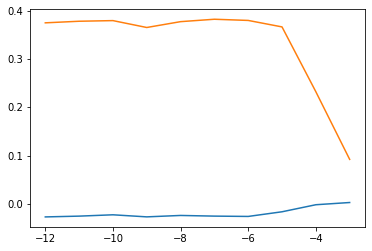

In [22]:
plt.plot(np.log(np.array(l2list)[:, 0]) / np.log(10), np.array(l2list)[:, 2] - np.array(l2list)[:, 1])
plt.plot(np.log(np.array(l2list)[:, 0]) / np.log(10), np.array(l2list)[:, 2])

In [91]:
self = m
v = 0
if self.p["dssm_l2"]:
    for weights_ in [self.u_dssm.weights, self.g_dssm.weights]:
        for weight_ in weights_:
            v += tf.reduce_sum(weight_ * weight_) * self.p["dssm_l2"]
            print(weight_)
v

<tf.Variable 'dense_58/kernel:0' shape=(100, 100) dtype=float32, numpy=
array([[-7.9740467e-34,  2.0360795e-33, -4.4518928e-33, ...,
        -4.4267920e-33, -5.3418403e-34,  5.0569763e-33],
       [-1.8804310e-33, -1.8777980e-33, -1.4001901e-33, ...,
        -1.5055640e-33,  1.2576981e-33, -2.3071802e-33],
       [ 1.9859481e-34, -3.2871844e-33, -1.7170977e-33, ...,
        -1.3686475e-33,  3.4912285e-33,  1.8165941e-33],
       ...,
       [ 2.3747416e-33,  1.8064645e-33, -4.3542570e-33, ...,
        -2.7569288e-33, -1.5807681e-33, -5.6899385e-33],
       [ 3.7058315e-33,  5.9529756e-33, -1.3113678e-33, ...,
        -1.5264362e-33, -8.2757025e-34, -1.7291470e-33],
       [ 6.3284621e-34,  1.9288670e-33, -5.1762108e-33, ...,
        -1.6326110e-33,  5.9155401e-33,  1.1289804e-33]], dtype=float32)>
<tf.Variable 'dense_58/bias:0' shape=(100,) dtype=float32, numpy=
array([-1.67454203e-33, -2.53377440e-33,  5.78661559e-33, -9.77833506e-34,
       -9.50999542e-34,  5.59624869e-33,  2.695319

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

In [60]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004877878, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4851858407079646 2195.9683 2260
np.mean(results), mse, len(results) =  0.43146100691016787 2182.3132 1013


(0.4851858407079646, 0.43146100691016787)

In [61]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004480459, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.509146017699115 1241.5701 2260
np.mean(results), mse, len(results) =  0.4492102665350444 1216.9811 1013


(0.509146017699115, 0.4492102665350444)

In [62]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0043484, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4418849557522124 302.6887 2260
np.mean(results), mse, len(results) =  0.41613030602171763 301.89804 1013


(0.4418849557522124, 0.41613030602171763)

In [63]:
N = 5000

In [64]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004762494, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5030132743362832 3137.0042 2260
np.mean(results), mse, len(results) =  0.44550839091806516 3120.9895 1013


(0.5030132743362832, 0.44550839091806516)

In [65]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0053637824, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5270353982300885 1921.7141 2260
np.mean(results), mse, len(results) =  0.45462981243830203 1962.4056 1013


(0.5270353982300885, 0.45462981243830203)

In [66]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004742319, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.45007522123893806 736.8847 2260
np.mean(results), mse, len(results) =  0.42163869693978284 735.5258 1013


(0.45007522123893806, 0.42163869693978284)

In [67]:
N = 5000

In [68]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004749834, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.49929203539823014 3047.4536 2260
np.mean(results), mse, len(results) =  0.4371372161895361 2993.2097 1013


(0.49929203539823014, 0.4371372161895361)

In [69]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004817963, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5263893805309734 1909.4731 2260
np.mean(results), mse, len(results) =  0.45605133267522213 1898.02 1013


(0.5263893805309734, 0.45605133267522213)

In [70]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004276596, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4491371681415929 705.44073 2260
np.mean(results), mse, len(results) =  0.4215498519249753 703.9983 1013


(0.4491371681415929, 0.4215498519249753)

In [71]:
N = 7000

In [72]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0049514812, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5114336283185842 5668.9243 2260
np.mean(results), mse, len(results) =  0.44461006910167816 5739.356 1013


(0.5114336283185842, 0.44461006910167816)

In [73]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0051233373, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5403938053097345 2459.8289 2260
np.mean(results), mse, len(results) =  0.4615004935834156 2461.2917 1013


(0.5403938053097345, 0.4615004935834156)

In [74]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0044722497, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4539159292035398 1257.0953 2260
np.mean(results), mse, len(results) =  0.42438302073050344 1255.6047 1013


(0.4539159292035398, 0.42438302073050344)

In [75]:
N = 10000

In [76]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': False,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.005124652, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5136194690265486 7360.148 2260
np.mean(results), mse, len(results) =  0.4441855873642646 7340.0337 1013


(0.5136194690265486, 0.4441855873642646)

In [77]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0050623715, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5432477876106194 3677.865 2260
np.mean(results), mse, len(results) =  0.46202369200394866 3670.6875 1013


(0.5432477876106194, 0.46202369200394866)

In [78]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0043231845, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.45828761061946904 2290.7322 2260
np.mean(results), mse, len(results) =  0.426061204343534 2289.0903 1013


(0.45828761061946904, 0.426061204343534)

In [43]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.004598814, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.44826548672566374 269.827 2260
np.mean(results), mse, len(results) =  0.4227245804540967 267.14542 1013


(0.44826548672566374, 0.4227245804540967)

In [44]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'ApproxNDCGLoss',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.07293427, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.10981858407079646 1148.0542 2260
np.mean(results), mse, len(results) =  0.11333662388943731 1162.9061 1013


(0.10981858407079646, 0.11333662388943731)

In [45]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': False,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0041721365, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.44133185840707967 301.55923 2260
np.mean(results), mse, len(results) =  0.41663376110562683 299.74582 1013


(0.44133185840707967, 0.41663376110562683)

In [46]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'mse',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(0.7744811, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.40189823008849557 0.7744809 2260
np.mean(results), mse, len(results) =  0.39785784797630797 0.7791881 1013


(0.40189823008849557, 0.39785784797630797)

In [47]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'qmse',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(0.24532242, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3975530973451328 73.67433 2260
np.mean(results), mse, len(results) =  0.39475814412635735 73.58957 1013


(0.3975530973451328, 0.39475814412635735)

In [48]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'mse',
    # 'loss_batch': 128, 'loss_q': 0.99,
    'n': 100,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(72.135, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3355619469026549 72.13495 2260
np.mean(results), mse, len(results) =  0.3346594274432379 72.04932 1013


(0.3355619469026549, 0.3346594274432379)

In [56]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0.1,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': False,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'mse',
    # 'loss_batch': 128, 'loss_q': 0.99,
    'n': 1000,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(73.81455, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3749469026548673 73.81461 2260
np.mean(results), mse, len(results) =  0.370898321816387 73.72918 1013


(0.3749469026548673, 0.370898321816387)

In [57]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0.1,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': False,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'mse',
    # 'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(73.81376, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3774778761061947 73.81385 2260
np.mean(results), mse, len(results) =  0.37365251727541954 73.72859 1013


(0.3774778761061947, 0.37365251727541954)

In [58]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0.1,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': False,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0039051883, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.42430973451327436 118.259094 2260
np.mean(results), mse, len(results) =  0.4102369200394867 117.62085 1013


(0.42430973451327436, 0.4102369200394867)

In [59]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0.1,
    'train_matrix': True,
    'train_dssm': False,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0040041166, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.43679646017699114 1538.5527 2260
np.mean(results), mse, len(results) =  0.4224876604146101 1538.9983 1013


(0.43679646017699114, 0.4224876604146101)

In [60]:
N = 20000

In [62]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.005444854, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5562433628318584 7699.4463 2260
np.mean(results), mse, len(results) =  0.47066140177690025 7571.1646 1013


(0.5562433628318584, 0.47066140177690025)

In [65]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'ApproxNDCGLoss',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.09138906, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.0676858407079646 30260742.0 2260
np.mean(results), mse, len(results) =  0.07054294175715696 33249346.0 1013


(0.0676858407079646, 0.07054294175715696)

In [66]:
N = 30000

In [67]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.005307315, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5678938053097345 13690.404 2260
np.mean(results), mse, len(results) =  0.4688252714708786 13718.514 1013


(0.5678938053097345, 0.4688252714708786)

In [68]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.9,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0077783526, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.33758849557522125 28479.803 2260
np.mean(results), mse, len(results) =  0.3218460019743337 27694.84 1013


(0.33758849557522125, 0.3218460019743337)

In [69]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': True, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 256, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0030351272, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5790929203539823 12195.394 2260
np.mean(results), mse, len(results) =  0.4625765054294176 12066.365 1013


(0.5790929203539823, 0.4625765054294176)

In [70]:
N

30000

In [71]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 256, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0031585894, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5747743362831859 9198.897 2260
np.mean(results), mse, len(results) =  0.46651530108588357 9084.219 1013


(0.5747743362831859, 0.46651530108588357)

In [72]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)
last loss =  tf.Tensor(-0.0053976728, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5612743362831859 9028.678 2260
np.mean(results), mse, len(results) =  0.46571569595261597 8984.45 1013


(0.5612743362831859, 0.46571569595261597)

In [ ]:
m = CBKnnV0(ctx, fit_kwargs={
    'c': 0.1,
    'train_matrix': True,
    'train_dssm': True,
    'train_vbias': True,
    'train_popbias': False, 'train_bias': False,
    'verbose': False, 'loss': 'softmax',
    'loss_batch': 128, 'loss_q': 0.99,
    'n': N,
    # 'ubatch': 512
})
m.fit()
m.get_score("train"), m.get_score("test")

self.embed_users['train'].shape =  (2260, 100)
self.embed_games.shape =  (10031, 100)
self.games2users.shape =  (100, 100)
self.core_users_scores.shape =  (100, 10031)
self.core_users_embs.shape =  (100, 100)
self.ge_users.shape =  (2260, 100)


In [79]:
import torch

In [80]:
class AnnCUR(Popular):
    def __init__(self, ctx, oracle=False):
        super().__init__(ctx)
        self.oracle = oracle
        
        self.key_cols_idx = np.array(sorted(ctx.key_games))
        rows_idx = np.arange(ctx.get_relevs("train").shape[0])
        
        self.cur = matrix_approx_zeshel.CURApprox(
            rows=torch.from_numpy(ctx.get_relevs("train")),
            cols=torch.from_numpy(ctx.get_relevs("train")[:, self.key_cols_idx]),
            row_idxs=rows_idx,
            col_idxs=self.key_cols_idx,
            approx_preference="rows",
            A=(torch.from_numpy(ctx.get_relevs("train")) if oracle else None)
        )
        
        
        
    def get_user_scores(self, t):
        return self.ctx.get_relevs(t)
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        key_relevs = torch.from_numpy(ctx.get_relevs(t)[:, self.key_cols_idx])
        return self.cur.get_complete_row(key_relevs)
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [81]:
m = AnnCUR(ctx)
m.fit()
m.get_score("train"), m.get_score("test")

np.mean(results), mse, len(results) =  0.4881150442477877 0.18208094 2260
np.mean(results), mse, len(results) =  0.4666929911154985 0.20506908 1013


(0.4881150442477877, 0.4666929911154985)

In [54]:
m.cur.U.shape, m.cur.latent_cols.shape

(torch.Size([100, 2260]), torch.Size([100, 10031]))

In [34]:
m = AnnCUR(ctx, oracle=True)
m.fit()
m.get_score("train"), m.get_score("test")

/home/shevkunov/nanny/matrix_approx_zeshel.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.U = torch.tensor(np.linalg.pinv(self.C)) @ torch.tensor(A) @ torch.tensor(np.linalg.pinv(self.R))


np.mean(results), mse, len(results) =  0.4863407079646018 0.3728227 2260
np.mean(results), mse, len(results) =  0.46132280355380056 0.3958743 1013


(0.4863407079646018, 0.46132280355380056)

In [1]:
import collections
import pickle
import numpy as np
import tqdm
import os
import gc

import matplotlib.pyplot as plt


def load(limit, raw_path = "stand/log.local.logtime2.txt", path = "log.local.logtime2.bin", key_games = None, seed = 17, det_attempts = 0):
    readvector = lambda s : np.array(list(map(float, s.strip()[1:-2].split(","))))
    requests = list()
    docembs = collections.defaultdict(dict)

    if os.path.isfile(path):
        with open(path, "rb") as f:
            flimit, frequests, fdocembs = pickle.load(f)
            if flimit == limit:
                requests, docembs = frequests, fdocembs
            else:
                print(f"WARN: buffered limit is different, {flimit} != {limit}, reloading...")

    if not requests:
        with open(raw_path) as f:
            req = list()
            reqid = None
            models = list()
            prevreqmodel = None
            reqmodel = dict()
            prevmodelid = -1
            bannermodelid = -1
            for i, line in tqdm.tqdm_notebook(enumerate(f)):
                if line.startswith("Model = 6;"):
                    prevreqmodel = reqmodel
                    reqmodel = dict()

                if line.startswith("Model = "):
                    spl = line.split(" ")
                    prevmodelid = int(spl[2][:-1])
                    bannermodelid = max(bannermodelid , prevmodelid)
                    reqmodel[prevmodelid] = readvector(spl[3])
                elif line.startswith("dbid"):
                    spl = line.split(" ")
                    dbid = int(spl[1][:-1])
                    docembs[bannermodelid][dbid] = readvector(spl[2])
                elif line.startswith("seed"):
                    if len(requests) >= limit:
                        break
                    if req:
                        requests.append((reqid, prevreqmodel, sorted(req)))
                        req = list()
                    reqid = "$_" + (line.split()[1] + "_" + line.split()[3])
                else:
                    req.append(
                        (int(line.split()[0]), float(line.split()[1]))
                    )
        
        with open(path, "wb") as f:
            pickle.dump((limit, requests, docembs), f)

    games_count = len(requests[0][2])
    assert games_count == 16514
    requests = [r for r in requests if len(r[2]) == games_count]
    
    print([(i, len(docembs[i].keys())) for i in docembs])  # should be equal
    docblocks = {
        mid : np.array([x[1] for x in sorted(list(docembs[mid].items()))])
        for mid in docembs
    }
    
    class EvalContext:
        def __init__(self, games_count = games_count, key_size = 100, train_size = 0.7, key_games = None, seed = 17, det_attempts = 0):
            self.games_count = games_count
            self.key_games = (
                np.random.choice(np.arange(games_count), key_size, replace=False)
                if key_games is None else
                key_games
            )

            self.requests = requests
            np.random.seed(seed)
            np.random.shuffle(self.requests)
            
            self.try_det_attempts(det_attempts)

            self.key_reqs = self.requests[:key_size + 1]
            self.key_reqs_idx = np.arange(key_size + 1)

            self.train_split = int(len(self.requests) * train_size)

            assert key_size + 1 < self.train_split

            self.train_reqs = self.requests[key_size + 1: self.train_split]
            self.test_reqs = self.requests[self.train_split:]

            self.slices = ["key", "train", "test"]
            print(len(self.key_reqs), len(self.train_reqs), len(self.test_reqs))

            self.docblocks = docblocks
            
        def get_top_games(self):
            if not hasattr(self, "top_games"):
                embed_games = np.array([
                    np.array([r[2][g_i][1] for r in self.get_requests("train")])
                    for g_i in range(self.games_count)
                ])

                self.embed_games_mean = embed_games.mean(axis=1)
                self.top_games_all = (-self.embed_games_mean).argsort()
                self.top_games = self.top_games_all[:len(self.key_games)]

            return self.top_games
        
        def set_top_games_as_key(self):
            self.key_games = self.get_top_games()
            return self
        
        def try_det_attempts(self, det_attempts, model_id = 6):
            def get_det(r, r_i_array):
                kr = np.array([
                    r[r_i][1][model_id]
                    for r_i in r_i_array[:100]
                ])
                return np.abs(np.linalg.det(kr[:kr.shape[1], :]))

            best_i_array = np.arange(len(self.requests))

            for _ in range(det_attempts):
                # print("try update key_reqs...")
                
                r_i_array = np.arange(len(self.requests))
                np.random.shuffle(r_i_array)
                
                n, o = get_det(self.requests, r_i_array), get_det(self.requests, best_i_array)
                # print(n, o)
                if n > o:
                    best_i_array = r_i_array
                    # print("updated!")

            print("Best det = ", get_det(self.requests, best_i_array))
            
            new_requests = [
                self.requests[i]
                for i in best_i_array
            ]
            
            del self.requests
            gc.collect()

            self.requests = new_requests
            print(get_det(self.requests, np.arange(len(self.requests))))

        def get_requests(self, t = "train"):
            if t == "train":
                return self.train_reqs
            elif t == "key":
                return self.key_reqs
            elif t == "test":
                return self.test_reqs
            else:
                assert False

    return EvalContext(key_games = key_games, seed = seed, det_attempts = det_attempts)

# Custom preparations

In [2]:
import json

def get_cat_top(ctx, games_all_json = "games-all.json", max_per_category = 4):
    with open(games_all_json) as f:
        games_all = json.loads(f.read())

    game2category = {
        g_i["appID"] : g_i["categoryName"]["categories"]
        for g_i in games_all
    }


    flat_game_id_2_app_id = {i: row[0] for i, row in enumerate(ctx.requests[0][2])}

    all_category = set()
    for i, c in game2category.items():
        for c_i in c:
            all_category.add(c_i)

    def get_cat(top_games):
        flat_game_id_2_app_id = {i: row[0] for i, row in enumerate(ctx.requests[0][2])}
        top_cat = set()
        for g_i in top_games:
            app_id = flat_game_id_2_app_id[g_i]
            if app_id in game2category:
                for c_i in game2category[app_id]:
                    top_cat.add(c_i)
            else:
                # print("nf")
                pass
        return top_cat

    cat_top = list()
    cobs = collections.defaultdict(int)

    top_games = ctx.get_top_games()

    for g_i in ctx.top_games_all:
        app_id = flat_game_id_2_app_id[g_i]
        categories = tuple(sorted(game2category[app_id] if app_id in game2category else []))

        skip = False
        for cs_i in categories:
            if cobs[cs_i] >= max_per_category:
                skip = True
                break

        if skip:
            continue

        for cs_i in categories:
            cobs[cs_i] += 1

        cat_top.append(g_i)
        if len(cat_top) == len(top_games):
            break

    return cat_top

# Models

In [3]:
class Popular:
    def __init__(self, ctx):
        self.ctx = ctx
        self.game_avg_scores = {
            t : self.get_user_scores(t).mean(axis = 0)
            for t in self.ctx.slices
        }
        
    def get_user_scores(self, t):
        return np.array([
            np.array([g_i[1] for g_i in r[2]])
            for r in self.ctx.get_requests(t)
        ])
    
    def get_user_embs(self, t):
        assert False
    
    def get_game_embs(self):
        assert False

    def fit(self, t = "train"):
        self.top_logits = self.game_avg_scores[t]
        self.top = np.argsort(-self.top_logits)

    def recommend(self, t):
        return [self.top_logits for _ in self.get_user_scores(t)]
    
    def get_score(self, t, topsize = 100):       
        recs = np.array(self.recommend(t))
        trus = self.get_user_scores(t)

        mse = np.mean((recs - trus) ** 2)

        recs = np.argsort(-recs, axis=1)[:, :topsize]
        trus = np.argsort(-trus, axis=1)[:, :topsize]

        ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 
            
        results = [
            ev(rec, tru) / float(topsize)
            for rec, tru in zip(recs,trus)
        ]

        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

        return np.mean(results)

In [47]:
import tensorflow as tf
import copy
import tensorflow_ranking as tfr

DEFAULT_FIT_KWARGS = {
    "learning_rate": 0.001,
    "n": 500,
    "c": 5000,
    "train_popbias": False,
    "train_bias": False,
    "train_vbias": False,
    "verbose": True,
    "train_dssm": False,
    "loss": "mse",
    "ubatch": 1e9,
}

class CBKnnV0(Popular):
    def __init__(self, ctx, fit_kwargs = dict()):
        super().__init__(ctx)
        
        self.fit_kwargs = fit_kwargs
        
        self.embed_users = {
            t : np.array([
                    np.array([r_i[2][i][1] for i in ctx.key_games])
                    for r_i in ctx.get_requests(t)
                ])
            for t in ctx.slices
        }
        self.embed_users_mean = {
            t : self.embed_users[t].mean(axis = 0)
            for t in ctx.slices
        }
        # embed_users = embed_users - embed_users_mean
        print("self.embed_users['train'].shape = ", self.embed_users['train'].shape )
        
        self.embed_games = np.array([
            np.array([r[2][g_i][1] for r in ctx.get_requests("key")])
            for g_i in range(ctx.games_count)
        ])
        
        self.embed_games_mean = self.embed_games.mean(axis = 0)
        
        # embed_games = embed_games - embed_games_mean
        print("self.embed_games.shape = ", self.embed_games.shape)
        
        self.games_top_key = self.embed_games.mean(axis = 1)
        
        self.games2users = np.array([
            self.embed_games[g_i]
            for g_i in ctx.key_games
        ])
        print("self.games2users.shape = ", self.games2users.shape)
        
        self.core_users_scores = np.array([
            np.array([g_i[1] for g_i in r[2]])
            for r in ctx.get_requests("key")
        ])
        print("self.core_users_scores.shape = ", self.core_users_scores.shape)
        
        self.core_users_embs = self.embed_users["key"]
        print("self.core_users_embs.shape = ", self.core_users_embs.shape)
        
        self.ge_users = (
            (self.embed_users["train"].T / self.embed_users["train"].mean(axis=1)).T @ self.games2users
        )
        # ge_users = embed_users @ games2users
        print("self.ge_users.shape = ", self.ge_users.shape)
    
    def __repr__(self):
        return "CbKnn(" + str(self.fit_kwargs) + ")"
        
    # inherited   
    # def get_user_scores(self, t):
    
    def get_user_embs(self, t):
        return (self.embed_users[t] - self.embed_users_mean["train"]) / self.embed_users[t].std(axis=0)
        # return self.embed_users[t]
    
    def get_game_embs(self):
        return (self.embed_games - self.embed_games.mean(axis=0)) / self.embed_games.std(axis=0)
        #return self.embed_games

    def fit(self, **kwargs):
        p = copy.copy(DEFAULT_FIT_KWARGS)
        p.update(self.fit_kwargs)
        p.update(kwargs)

        self.train_bias = p["train_bias"]
        self.train_vbias = p["train_vbias"]
        self.train_popbias = p["train_popbias"]
        self.train_dssm = p["train_dssm"]
        self.loss = p["loss"]

        train_user_scores = self.get_user_scores("train")
        train_user_embs = self.get_user_embs("train")
        game_embs = self.get_game_embs()
        
        initializer = tf.keras.initializers.GlorotUniform()
        values = initializer(shape=(train_user_embs.shape[1], game_embs.shape[1]))
        self.W = tf.Variable(values / 100., trainable = True) 
        self.pb = tf.Variable(1., trainable = True) 
        self.b = tf.Variable(0., trainable = True) 
        
        if p["verbose"]:
            print("self.W = ", self.W)
            print("0-loss = ", tf.reduce_mean((train_user_scores - 0) ** 2))
    
        opt =  tf.keras.optimizers.Adam(learning_rate=p["learning_rate"])

        if self.train_dssm:
            self.train_dssm = True

            dim = game_embs.shape[1]
            self.g_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation='relu'),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.g_dssm(game_embs)
            
            # dim = train_user_embs.shape[1]
            self.u_dssm = tf.keras.Sequential([
                tf.keras.layers.Dense(dim, activation='relu'),
                tf.keras.layers.Dense(dim, activation=None)
            ])
            self.u_dssm(train_user_embs)
            
        if self.train_vbias:
            self.vb = tf.Variable(
                np.zeros_like(self.game_avg_scores["train"], dtype=np.float32),
                trainable = True
            ) 
        
        
        for i in range(p["n"]):
            def loss():
                def get_logits_scores(loss_batch = 1e9):
                    game_slice = None
                    
                    ubatch = p["ubatch"]
                    if ubatch >= train_user_scores.shape[0]:
                        train_user_embs_ = train_user_embs
                        scores_ = train_user_scores
                    else:
                        u_slice = np.random.choice(np.arange(train_user_scores.shape[0]), ubatch, replace = True)
                        train_user_embs_ = train_user_embs[u_slice]
                        scores_ = train_user_scores[u_slice]
                    
                    if loss_batch >= game_embs.shape[0]:
                        game_embs_ = game_embs
                        scores_ = scores_
                    else:
                        game_slice = np.random.choice(np.arange(game_embs.shape[0]), loss_batch, replace = True)
                        game_embs_ = game_embs[game_slice]
                        scores_ = scores_[:, game_slice]
                        
                    
                    logits = train_user_embs_ @ self.W @ game_embs_.T

                    if self.train_dssm:
                        logits += self.u_dssm(train_user_embs_) @ tf.transpose(self.g_dssm(game_embs_))
                    
                    if self.train_popbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.pb * self.game_avg_scores["train"]
                        else:
                            logits += self.pb * self.game_avg_scores["train"][game_slice]
                        
                    if self.train_vbias:
                        if loss_batch >= game_embs.shape[0]:
                            logits += self.vb
                        else:
                            logits += tf.gather(self.vb, game_slice)
                        
                    if self.train_bias:
                        logits += self.b
                        
                    return logits, scores_
                        
                if self.loss == "mse":
                    logits, scores = get_logits_scores()
                    v = tf.reduce_mean((scores - logits) ** 2)
                elif self.loss == "qmse":
                    logits, scores = get_logits_scores()
                    q_mean = scores.mean(axis=1)
                    v = tf.reduce_mean(((scores.T - q_mean).T - logits) ** 2)
                elif self.loss == "ApproxNDCGLoss":
                    while True:
                        logits, scores = get_logits_scores(
                            loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))

                        v = tfr.keras.losses.ApproxNDCGLoss()(
                            scores.astype(np.float32),
                            logits
                        )
                    
                        if not tf.math.is_nan(v).numpy().any():
                            break
                        else:
                            if p["verbose"]:
                                print("nanloss ignored")
                elif self.loss == "softmax":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ))
                elif self.loss == "softmax_weighted":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    
                    qs = np.quantile(scores, p["loss_q"], axis=1)
                    v = -tf.reduce_mean(tf.where(
                        (scores.T >= qs.T).T,
                        tf.nn.softmax(logits, axis=1),
                        0
                    ) * scores)
                elif self.loss == "sigmoid_top_100":
                    logits, scores = get_logits_scores(
                        loss_batch = (64 if "loss_batch" not in p else p["loss_batch"]))
                    mask = np.argsort(-scores, axis=1) < 100
                    v = -tf.reduce_mean(
                        tf.math.log_sigmoid((2 * mask - 1) * logits)
                    )
                else:
                    assert False
                    
                v += tf.reduce_mean(self.W * self.W) * p["c"]
                
                if p["verbose"]:
                    print(v.numpy())
                
                return v

            weights = list()
            
            weights += [self.W]

            if self.train_dssm:
                weights += self.u_dssm.weights
                weights += self.g_dssm.weights
            
            if self.train_popbias:
                weights += [self.pb]

            if self.train_vbias:
                weights += [self.vb]   
                
            if self.train_bias:
                weights += [self.b]   
                
                
            opt.minimize(loss, weights)
        print("last loss = ", loss())

    def recommend(self, t):
        logits = self.get_user_embs(t) @ self.W @ self.get_game_embs().T
        
        if self.train_dssm:
            logits += self.u_dssm(self.get_user_embs(t)) @ tf.transpose(self.g_dssm(self.get_game_embs()))

        if self.train_popbias:
            logits += self.pb * self.game_avg_scores["train"]       
            
        if self.train_vbias:
            logits += self.vb
            
        if self.train_bias:
            logits += self.b
            
        return logits
    
    # inherited
    # def get_score(self, t, topsize = 100):
    
class DssmKnn(CBKnnV0):
    def __init__(self, ctx, modelid, fit_kwargs=dict()):
        super().__init__(ctx, fit_kwargs=fit_kwargs)
        self.modelid = modelid
        self.embed_games = ctx.docblocks[modelid]
        
    def __repr__(self):
        return "DssmKnn(" + str(self.modelid) + "," + str(self.fit_kwargs) + ")"
        
    def get_user_embs(self, t):
        return np.array([r[1][self.modelid] for r in self.ctx.get_requests(t)])
    
    def get_game_embs(self):
        return self.embed_games
    
def ev(mds, logs=None):
    for i in range(len(mds)):
        print("\n\n\n=======")
        print("model = ", mds[i])
        mds[i].fit()
        tr, te = mds[i].get_score("train"), mds[i].get_score("test")
        print(tr, te)
        if logs is not None:
            logs.append((
                repr(mds[i]),
                tr,
                te
            ))

# Evals

skipgramm-loss +1 -k

In [5]:
L = 7000
N = 30000
DA = 50

In [9]:
gc.collect()
ev([
    Popular(load(L, seed=17, det_attempts=DA).set_top_games_as_key())
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088



model =  <__main__.Popular object at 0x7f6291825128>
np.mean(results), mse, len(results) =  0.2893499685468652 5.200994032516979 4769
np.mean(results), mse, len(results) =  0.2885536398467433 5.111057961798107 2088
0.2893499685468652 0.2885536398467433


# VBias

In [10]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.9234528, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4410819878381211 569.7468524756292 4769
np.mean(results), mse, len(results) =  0.44074233716475103 556.2498093991791 2088
0.4410819878381211 0.44074233716475103


In [11]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.9221295, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4462235269448522 761.3309741188773 4769
np.mean(results), mse, len(results) =  0.44590038314176245 754.1762599943463 2088
0.4462235269448522 0.44590038314176245


In [12]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.9224163, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4526001258125393 333.60441956963723 4769
np.mean(results), mse, len(results) =  0.4533716475095786 332.57552655760287 2088
0.4526001258125393 0.4533716475095786


In [19]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.0038861663, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4201677500524219 601.045890073455 4769
np.mean(results), mse, len(results) =  0.41914272030651345 597.0926835425148 2088
0.4201677500524219 0.41914272030651345


In [14]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.89716226, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3592304466345146 5.689766624212362 4769
np.mean(results), mse, len(results) =  0.35880747126436785 5.587532527567979 2088
0.3592304466345146 0.35880747126436785


In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [15]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.0009398345, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.21509750471797026 46.95882226309893 4769
np.mean(results), mse, len(results) =  0.21477011494252873 45.963821664211295 2088
0.21509750471797026 0.21477011494252873


In [17]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.8875086, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.34774376179492555 5.607455448230633 4769
np.mean(results), mse, len(results) =  0.3490373563218391 5.482877868104295 2088
0.34774376179492555 0.3490373563218391


In [18]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 100 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 100})
last loss =  tf.Tensor(-0.0009899065, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.22026630320821977 69.95804100093825 4769
np.mean(results), mse, len(results) =  0.21947796934865899 68.84273933108938 2088
0.22026630320821977 0.21947796934865899


In [20]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.941658, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.570643740826169 243.4158815165602 4769
np.mean(results), mse, len(results) =  0.567514367816092 245.80382304674248 2088
0.570643740826169 0.567514367816092


In [21]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.94433635, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5698238624449571 226.80375896937562 4769
np.mean(results), mse, len(results) =  0.5645641762452107 226.04206330299468 2088
0.5698238624449571 0.5645641762452107


In [22]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.9380937, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5482092681903963 178.12355563789168 4769
np.mean(results), mse, len(results) =  0.5431178160919541 182.5616921091469 2088
0.5482092681903963 0.5431178160919541


In [23]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.005225352, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5353680016775005 657.2814445434437 4769
np.mean(results), mse, len(results) =  0.5337021072796935 651.643487141184 2088
0.5353680016775005 0.5337021072796935


In [30]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.36149323, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5019479974837492 39.42314853367618 4769
np.mean(results), mse, len(results) =  0.4974473180076629 38.93516938411505 2088
0.5019479974837492 0.4974473180076629


In [24]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90800226, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4416837911511847 12.476248736170621 4769
np.mean(results), mse, len(results) =  0.43852969348659004 12.510016959351656 2088
0.4416837911511847 0.43852969348659004


In [25]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0024618355, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.33921786538058296 27.71175784497731 4769
np.mean(results), mse, len(results) =  0.3375478927203065 27.68226169792116 2088
0.33921786538058296 0.3375478927203065


In [26]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90312105, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.43557349549171737 14.01792014794912 4769
np.mean(results), mse, len(results) =  0.43261973180076624 14.152900767023766 2088
0.43557349549171737 0.43261973180076624


In [27]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0026439289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.32375760117425034 58.094277847920964 4769
np.mean(results), mse, len(results) =  0.3239942528735632 59.33090048667044 2088
0.32375760117425034 0.3239942528735632


In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 3000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
    gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 3000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 3000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 10000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 10000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 10000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': False,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    Popular(load(L, seed=17, det_attempts=DA).set_top_games_as_key())
])

In [ ]:
x = tf.Variable([10, 20, 30])
tf.gather(x, [1, 2])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 1e9, 'loss_q': 1. - 100./16000,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
L = 5000
N = 30000

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=50000).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=50000).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': True, 'train_bias': True,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

TBD - семплирование строк
- CE
- MAX Pooling
- all users

In [28]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.5861289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.37282658838330884 39.711724219574684 4769
np.mean(results), mse, len(results) =  0.37192528735632185 39.2116686842702 2088
0.37282658838330884 0.37192528735632185


In [29]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.61930263, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.35431746697420846 39.74103151059993 4769
np.mean(results), mse, len(results) =  0.35527777777777775 39.26967203496604 2088
0.35431746697420846 0.35527777777777775


In [31]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9499423, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.600620675193961 1276.4332872169043 4769
np.mean(results), mse, len(results) =  0.5960105363984675 1296.3925507737583 2088
0.600620675193961 0.5960105363984675


In [32]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})


KeyboardInterrupt: 

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [ ]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

In [20]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.941658, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.570643740826169 243.4158815165602 4769
np.mean(results), mse, len(results) =  0.567514367816092 245.80382304674248 2088
0.570643740826169 0.567514367816092


In [21]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.94433635, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5698238624449571 226.80375896937562 4769
np.mean(results), mse, len(results) =  0.5645641762452107 226.04206330299468 2088
0.5698238624449571 0.5645641762452107


In [22]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.9380937, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5482092681903963 178.12355563789168 4769
np.mean(results), mse, len(results) =  0.5431178160919541 182.5616921091469 2088
0.5482092681903963 0.5431178160919541


In [23]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.005225352, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5353680016775005 657.2814445434437 4769
np.mean(results), mse, len(results) =  0.5337021072796935 651.643487141184 2088
0.5353680016775005 0.5337021072796935


In [30]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.36149323, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5019479974837492 39.42314853367618 4769
np.mean(results), mse, len(results) =  0.4974473180076629 38.93516938411505 2088
0.5019479974837492 0.4974473180076629


In [24]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90800226, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4416837911511847 12.476248736170621 4769
np.mean(results), mse, len(results) =  0.43852969348659004 12.510016959351656 2088
0.4416837911511847 0.43852969348659004


In [25]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0024618355, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.33921786538058296 27.71175784497731 4769
np.mean(results), mse, len(results) =  0.3375478927203065 27.68226169792116 2088
0.33921786538058296 0.3375478927203065


In [26]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.90312105, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.43557349549171737 14.01792014794912 4769
np.mean(results), mse, len(results) =  0.43261973180076624 14.152900767023766 2088
0.43557349549171737 0.43261973180076624


In [27]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(-0.0026439289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.32375760117425034 58.094277847920964 4769
np.mean(results), mse, len(results) =  0.3239942528735632 59.33090048667044 2088
0.32375760117425034 0.3239942528735632


In [28]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.5861289, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.37282658838330884 39.711724219574684 4769
np.mean(results), mse, len(results) =  0.37192528735632185 39.2116686842702 2088
0.37282658838330884 0.37192528735632185


In [29]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'qmse',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 1000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'qmse', 'loss_batch': 128, 'loss_q': 0.99, 'n': 1000})
last loss =  tf.Tensor(0.61930263, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.35431746697420846 39.74103151059993 4769
np.mean(results), mse, len(results) =  0.35527777777777775 39.26967203496604 2088
0.35431746697420846 0.35527777777777775


In [31]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9499423, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.600620675193961 1276.4332872169043 4769
np.mean(results), mse, len(results) =  0.5960105363984675 1296.3925507737583 2088
0.600620675193961 0.5960105363984675


In [33]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.947908, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5975697211155379 1003.8214701982371 4769
np.mean(results), mse, len(results) =  0.5914463601532567 1013.531178097959 2088
0.5975697211155379 0.5914463601532567


In [44]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.946956, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5941790731809603 1116.5521584119715 4769
np.mean(results), mse, len(results) =  0.586522988505747 1116.2574327671837 2088
0.5941790731809603 0.586522988505747


In [45]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.005423398, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5919438037324387 2916.0637996061346 4769
np.mean(results), mse, len(results) =  0.5857710727969349 2943.4027904196996 2088
0.5919438037324387 0.5857710727969349


In [46]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9152643, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.47034598448312015 124.57544326288425 4769
np.mean(results), mse, len(results) =  0.4602394636015326 124.44437348021643 2088
0.47034598448312015 0.4602394636015326


In [47]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.003915394, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.45491297966030614 143.6231591707601 4769
np.mean(results), mse, len(results) =  0.4488266283524905 143.03593893854855 2088
0.45491297966030614 0.4488266283524905


In [48]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.91725177, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4792220591318935 112.01877624314724 4769
np.mean(results), mse, len(results) =  0.4667911877394636 111.78031351451894 2088
0.4792220591318935 0.4667911877394636


In [49]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.0039019585, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4520088068777522 186.63534255230354 4769
np.mean(results), mse, len(results) =  0.446360153256705 185.66832393046107 2088
0.4520088068777522 0.446360153256705


In [50]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.0041799066, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4723107569721115 200.4999508067162 4769
np.mean(results), mse, len(results) =  0.4668917624521073 200.54629991976623 2088
0.4723107569721115 0.4668917624521073


In [53]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.9238498, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5046173201929126 108.14846868112204 4769
np.mean(results), mse, len(results) =  0.49289272030651343 107.53222696714283 2088
0.5046173201929126 0.49289272030651343


In [51]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.0032832378, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.414919270287272 241.37036272609143 4769
np.mean(results), mse, len(results) =  0.4094061302681993 239.28359959086484 2088
0.414919270287272 0.4094061302681993


In [54]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': 5000 + 0 * N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 5000})
last loss =  tf.Tensor(-0.8790081, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4287838121199413 113.77265280408525 4769
np.mean(results), mse, len(results) =  0.42073275862068965 113.39317484106625 2088
0.4287838121199413 0.42073275862068965


In [60]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.97084105, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6211616691130215 10295.087340210097 4769
np.mean(results), mse, len(results) =  0.6124090038314176 10332.671176913673 2088
0.6211616691130215 0.6124090038314176


In [61]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': False, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': False, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.96870476, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6155084923464039 10531.332740907501 4769
np.mean(results), mse, len(results) =  0.6095689655172415 10425.673232304773 2088
0.6155084923464039 0.6095689655172415


In [62]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.9690291, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6152421891381841 7245.440096746725 4769
np.mean(results), mse, len(results) =  0.6113793103448275 7238.076955822821 2088
0.6152421891381841 0.6113793103448275


In [55]:
gc.collect()
ev([
    CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.005831809, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.6176850492765779 41307.83637296889 4769
np.mean(results), mse, len(results) =  0.6092911877394637 41676.8503839697 2088
0.6176850492765779 0.6092911877394637


In [63]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.95153993, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5223275319773537 803.6246029188035 4769
np.mean(results), mse, len(results) =  0.49438218390804595 799.6715259210562 2088
0.5223275319773537 0.49438218390804595


In [56]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.00464255, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5208114908785909 2708.7322439794784 4769
np.mean(results), mse, len(results) =  0.4985919540229885 2678.253527155522 2088
0.5208114908785909 0.4985919540229885


In [64]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.95220166, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5221430069196895 879.4392904503836 4769
np.mean(results), mse, len(results) =  0.4912978927203065 874.1787072067044 2088
0.5221430069196895 0.4912978927203065


In [57]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.0046054116, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.515485426714196 2837.4399690608266 4769
np.mean(results), mse, len(results) =  0.49353927203065134 2844.126859266893 2088
0.515485426714196 0.49353927203065134


In [67]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.9562866, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5399832249947579 891.5962733474038 4769
np.mean(results), mse, len(results) =  0.5097557471264367 899.3103794738361 2088
0.5399832249947579 0.5097557471264367


In [58]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.0049295695, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.5369364646676451 3397.702223300059 4769
np.mean(results), mse, len(results) =  0.5132231800766284 3360.3373926538325 2088
0.5369364646676451 0.5132231800766284


In [68]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'ApproxNDCGLoss',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'ApproxNDCGLoss', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.9470592, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.4569259802893688 782.8916174505752 4769
np.mean(results), mse, len(results) =  0.43693965517241373 780.0001495607916 2088
0.4569259802893688 0.43693965517241373


In [59]:
gc.collect()
ev([
    DssmKnn(load(L, seed=17, det_attempts=DA).set_top_games_as_key(), 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'softmax',
            'loss_batch': 128, 'loss_q': 0.99,
            'n': N,
            # 'ubatch': 512
        }
    )
])

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'softmax', 'loss_batch': 128, 'loss_q': 0.99, 'n': 30000})
last loss =  tf.Tensor(-0.0036828914, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.46145313482910466 3091.061999618546 4769
np.mean(results), mse, len(results) =  0.44371647509578543 3121.3879575103147 2088
0.46145313482910466 0.44371647509578543


In [ ]:
-Лучшие ключи в терминах векторов таргетов
- итеративый их выбор
- разложение матрицы

In [ ]:
POPBIAS - вектор, BIAS - число. Нужен OFFSET - trainable popbias

# Нужно ли потом вообще считать CB?

In [72]:
m = CBKnnV0(load(L, seed=17, det_attempts=DA).set_top_games_as_key(),
    fit_kwargs={
        'c': 0, 'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': False,
        'verbose': False, 'loss': 'softmax',
        'loss_batch': 128, 'loss_q': 0.99,
        'n': N,
        # 'ubatch': 512
    }
)

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088
self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)


In [73]:
m.fit()

last loss =  tf.Tensor(-0.0058211144, shape=(), dtype=float32)


In [74]:
dm = DssmKnn(m.ctx, 8,
    fit_kwargs={
        'c': 0, 'train_dssm': True,
        'train_vbias': True,
        'train_popbias': True, 'train_bias': False,
        'verbose': False, 'loss': 'softmax',
        'loss_batch': 128, 'loss_q': 0.99,
        'n': N,
        # 'ubatch': 512
    }
)

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)


In [75]:
dm.fit()

last loss =  tf.Tensor(-0.0061836843, shape=(), dtype=float32)


In [77]:
dm.get_score("test")

np.mean(results), mse, len(results) =  0.5207279693486591 2999.915457825084 2088


0.5207279693486591

In [78]:
m.get_score("test")

np.mean(results), mse, len(results) =  0.6092145593869731 34702.44711922175 2088


0.6092145593869731

In [83]:
self = m
t = "test"
topsize_recs = 200
topsize_trus = 100

recs = np.array(self.recommend(t))
trus = self.get_user_scores(t)

mse = np.mean((recs - trus) ** 2)

recs = np.argsort(-recs, axis=1)[:, :topsize_recs]
trus = np.argsort(-trus, axis=1)[:, :topsize_trus]

ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

results = [
    ev(rec, tru) / float(topsize)
    for rec, tru in zip(recs,trus)
]

print("np.mean(results), mse, len(results) = ",
      np.mean(results), mse, len(results))

np.mean(results)

np.mean(results), mse, len(results) =  0.7974904214559386 34702.44711922175 2088


0.7974904214559386

In [96]:
def get_score_custom(self, t, topsize_recs, topsize_trus, verbose=False):
    recs = np.array(self.recommend(t))
    trus = self.get_user_scores(t)

    mse = np.mean((recs - trus) ** 2)

    recs = np.argsort(-recs, axis=1)[:, :topsize_recs]
    trus = np.argsort(-trus, axis=1)[:, :topsize_trus]

    ev = lambda rec_, real_ : len((set(rec_).intersection(set(real_)))) 

    results = [
        ev(rec, tru) / float(topsize_trus)
        for rec, tru in zip(recs,trus)
    ]

    if verbose:
        print("np.mean(results), mse, len(results) = ",
              np.mean(results), mse, len(results))

    return np.mean(results)

In [94]:
get_score_custom(m, "test",  100, 100), get_score_custom(dm, "test",  100, 100)

np.mean(results), mse, len(results) =  0.6092145593869731 34702.44711922175 2088
np.mean(results), mse, len(results) =  0.5207279693486591 2999.915457825084 2088


(0.6092145593869731, 0.5207279693486591)

NameError: name 'plt' is not defined

In [104]:
ycm = list()
ydm = list()
x = list()

for i in [1] + list(range(50, 500, 50)):
    x.append(i)
    ycm.append(get_score_custom(m, "test",  i, i))
    ydm.append(get_score_custom(dm, "test",  i + 100, i))
    print(i, "->", ycm[-1], ydm[-1])

1 -> 0.2653256704980843 0.835727969348659
50 -> 0.568639846743295 0.7439367816091955
100 -> 0.6092145593869731 0.7086350574712644
150 -> 0.6353991060025543 0.6937100893997445
200 -> 0.6537763409961685 0.685308908045977
250 -> 0.6695 0.6808218390804598
300 -> 0.680603448275862 0.6778208812260537
350 -> 0.6902723043240285 0.6768773946360154
400 -> 0.6988505747126437 0.6769612068965518
450 -> 0.7057269050659855 0.6772041294167732


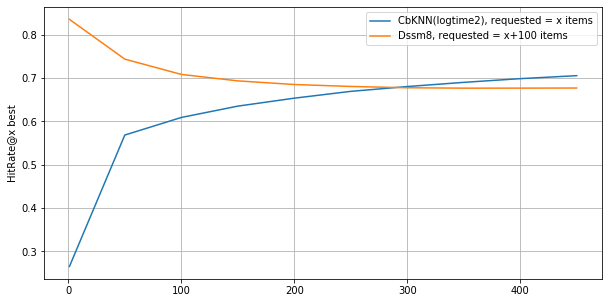

In [107]:
plt.figure(figsize=(10, 5))
plt.plot(x, ycm, label="CbKNN(logtime2), requested = x items")
plt.plot(x, ydm, label="Dssm8, requested = x+100 items")
plt.ylabel("HitRate@x best")
plt.legend()
plt.grid()
plt.show()

In [108]:
ycm = list()
ydm = list()
x = list()

for i in [1] + list(range(50, 500, 50)):
    x.append(i)
    ycm.append(get_score_custom(m, "test",  i, 100))
    ydm.append(get_score_custom(dm, "test",  i + 100, 100))
    print(i, "->", ycm[-1], ydm[-1])

1 -> 0.009760536398467433 0.5236877394636016
50 -> 0.39091475095785444 0.6339750957854408
100 -> 0.6092145593869731 0.7086350574712644
150 -> 0.7281465517241379 0.7617097701149426
200 -> 0.7974904214559386 0.8004166666666667
250 -> 0.8426484674329501 0.8292959770114943
300 -> 0.8731130268199233 0.8518534482758621
350 -> 0.8952538314176245 0.8704980842911877
400 -> 0.9113697318007663 0.8847988505747126
450 -> 0.9236494252873563 0.8974137931034483


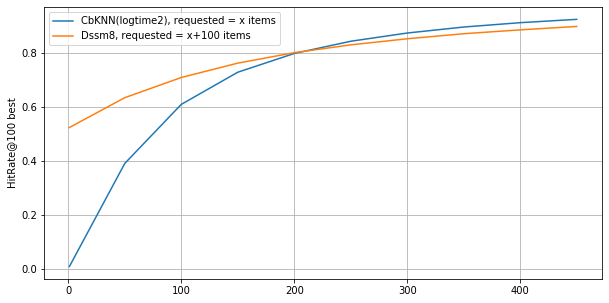

In [110]:
plt.figure(figsize=(10, 5))
plt.plot(x, ycm, label="CbKNN(logtime2), requested = x items")
plt.plot(x, ydm, label="Dssm8, requested = x+100 items")
plt.ylabel("HitRate@100 best")
plt.legend()
plt.grid()
plt.show()

In [115]:
ycm = list()
ydm = list()
x = list()

for i in [1] + list(range(50, 5050, 50)):
    x.append(i)
    ycm.append(get_score_custom(m, "test",  i, 1))
    ydm.append(get_score_custom(dm, "test",  i + 100, 1))
    print(i, "->", ycm[-1], ydm[-1])

1 -> 0.2653256704980843 0.835727969348659
50 -> 0.7605363984674329 0.8740421455938697
100 -> 0.8117816091954023 0.899904214559387
150 -> 0.8352490421455939 0.9118773946360154
200 -> 0.85727969348659 0.9209770114942529
250 -> 0.8716475095785441 0.928639846743295
300 -> 0.882183908045977 0.9377394636015326
350 -> 0.8912835249042146 0.9425287356321839
400 -> 0.9013409961685823 0.9501915708812261
450 -> 0.9090038314176245 0.9540229885057471
500 -> 0.9161877394636015 0.9573754789272031
550 -> 0.9219348659003831 0.9602490421455939
600 -> 0.9276819923371648 0.9621647509578544
650 -> 0.9305555555555556 0.9688697318007663
700 -> 0.9343869731800766 0.9712643678160919
750 -> 0.9367816091954023 0.9722222222222222
800 -> 0.9401340996168582 0.9746168582375478
850 -> 0.9454022988505747 0.9760536398467433
900 -> 0.9458812260536399 0.9774904214559387
950 -> 0.9501915708812261 0.9794061302681992
1000 -> 0.9525862068965517 0.9808429118773946
1050 -> 0.9568965517241379 0.9813218390804598
1100 -> 0.9578544

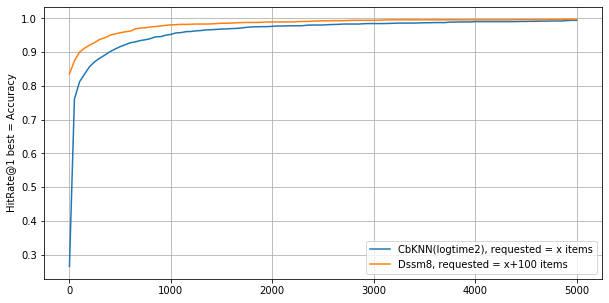

In [116]:
plt.figure(figsize=(10, 5))
plt.plot(x, ycm, label="CbKNN(logtime2), requested = x items")
plt.plot(x, ydm, label="Dssm8, requested = x+100 items")
plt.ylabel("HitRate@1 best = Accuracy")
plt.legend()
plt.grid()
plt.show()

<hr>

In [7]:
ctx = load(L, seed=17, det_attempts=DA).set_top_games_as_key()
pass

[(6, 16514), (7, 16514), (8, 16514), (9, 16514)]
Best det =  2.6095219944820717e-120
2.6095219944820717e-120
101 4769 2088


In [20]:
N = 100

In [10]:
gc.collect()
ev([
    DssmKnn(ctx, 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[ 1.3099855e-03,  9.4640342e-04,  1.5870988e-04, ...,
         2.3911759e-04,  2.0618588e-04,  1.1041879e-03],
       [-6.8015151e-04,  3.9811939e-04,  6.8818463e-04, ...,
         3.9022134e-04, -2.0935535e-05,  7.5513555e-04],
       [-3.1250805e-04,  1.3498532e-03, -1.6690519e-03, ...,
         1.0845968e-03, -1.0286078e-04, -2.4271444e-04],
       ...,
       [-1.3376847e-03, -1.3134675e-03,  1.7126497e-03, ...,
         1.6389719e-03, -1.1626628e-03,  1.5400136e-03],
       [ 1.1873100e-03,  1.3876632e-04

In [13]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 101) dtype=float32, numpy=
array([[-0.00147542,  0.00164654,  0.00094504, ...,  0.00095823,
         0.0005148 ,  0.0013789 ],
       [-0.00040909, -0.00163493, -0.00132024, ..., -0.0006525 ,
         0.00095906,  0.00120513],
       [-0.00126614,  0.00104214, -0.00010766, ...,  0.00164741,
         0.00071401,  0.00052066],
       ...,
       [-0.00032644, -0.00100515,  0.00045999, ..., -0.00032491,
        -0.00064912,  0.00094154],
       [-0.00132566,  0.00167471,  0.00048872, ...,  0.00018932,
         0.00021268, -0.00130056],
       [-0.000

In [21]:
gc.collect()
ev([
    DssmKnn(ctx, 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[ 8.8083296e-05, -3.9741979e-04, -1.6371228e-03, ...,
         1.5156246e-03, -1.6283884e-03,  7.7666849e-04],
       [ 4.6822146e-04, -7.9344603e-04, -3.8897365e-04, ...,
         5.3110928e-04,  1.1113489e-03, -1.1881053e-03],
       [-1.6695252e-03,  6.0376048e-04, -1.3862967e-03, ...,
         1.7143479e-03,  7.5556547e-04, -8.3044200e-04],
       ...,
       [ 9.6369744e-04,  6.8692357e-04,  1.4632281e-03, ...,
        -4.4951306e-04,  4.7117696e-04, -3.4639746e-04],
       [-1.6748339e-04,  1.3709819e-03

In [22]:
gc.collect()
ev([
    DssmKnn(ctx, 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[-1.0149053e-03, -1.3837368e-03,  7.2454975e-04, ...,
         1.6374808e-03, -1.5277691e-03,  1.4562279e-03],
       [-1.4980402e-03, -1.1954772e-03,  1.0170534e-03, ...,
         1.5366769e-03,  3.2000989e-05,  1.2048632e-03],
       [-7.3641137e-04, -1.1221744e-03, -1.3788426e-03, ...,
        -1.1639963e-03, -1.5210867e-03,  1.4383760e-03],
       ...,
       [ 2.3445905e-04,  2.0153373e-05, -1.3630245e-03, ...,
        -7.3897047e-04,  5.7532504e-04, -9.5205347e-04],
       [ 9.0605795e-04, -1.2355899e-03

In [23]:
gc.collect()
ev([
    DssmKnn(ctx, 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': True, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': True, 'loss': 'mse', 'n': 100})
self.W =  <tf.Variable 'Variable:0' shape=(100, 100) dtype=float32, numpy=
array([[-1.4129202e-03, -7.7697705e-04, -1.4862367e-03, ...,
        -8.3383732e-04, -1.7250107e-03,  7.2711048e-04],
       [-1.6245475e-03, -2.8165296e-04, -1.4183699e-04, ...,
         1.5978068e-03,  3.9347858e-04,  1.3677243e-03],
       [-1.0923435e-03,  1.1012050e-03,  1.2270871e-03, ...,
         9.9552723e-05, -8.1396109e-04,  1.3274312e-03],
       ...,
       [-6.6037558e-04,  9.5166417e-04, -1.8817275e-04, ...,
         1.5017509e-03,  1.7216989e-03,  1.2884855e-03],
       [ 3.3370897e-04, -1.4985213e-03

In [14]:
N = 1000

In [15]:
gc.collect()
ev([
    DssmKnn(ctx, 8,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(8,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.0807164, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.40834975885929964 1.0807162504829866 4769
np.mean(results), mse, len(results) =  0.40479406130268203 4.0971001001934155 2088
0.40834975885929964 0.40479406130268203


In [16]:
gc.collect()
ev([
    CBKnnV0(ctx,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  CbKnn({'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(0.42216286, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.496039001887188 0.422162868024669 4769
np.mean(results), mse, len(results) =  0.492418582375479 0.44902059845017595 2088
0.496039001887188 0.492418582375479


In [17]:
gc.collect()
ev([
    DssmKnn(ctx, 6,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(6,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.2194006, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3803837282449151 1.2194003766729133 4769
np.mean(results), mse, len(results) =  0.3769013409961686 4.261311384294862 2088
0.3803837282449151 0.3769013409961686


In [18]:
gc.collect()
ev([
    DssmKnn(ctx, 7,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(7,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.3214303, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3634682323338226 1.3214303049597298 4769
np.mean(results), mse, len(results) =  0.3615756704980843 4.160191452113321 2088
0.3634682323338226 0.3615756704980843


In [19]:
gc.collect()
ev([
    DssmKnn(ctx, 9,
        fit_kwargs={
            'c': 0, 'train_dssm': True,
            'train_vbias': True,
            'train_popbias': True, 'train_bias': False,
            'verbose': False, 'loss': 'mse',
            'n': N,
            # 'ubatch': 512
        }
    )
])

self.embed_users['train'].shape =  (4769, 100)
self.embed_games.shape =  (16514, 101)
self.games2users.shape =  (100, 101)
self.core_users_scores.shape =  (101, 16514)
self.core_users_embs.shape =  (101, 100)
self.ge_users.shape =  (4769, 101)



model =  DssmKnn(9,{'c': 0, 'train_dssm': True, 'train_vbias': True, 'train_popbias': True, 'train_bias': False, 'verbose': False, 'loss': 'mse', 'n': 1000})
last loss =  tf.Tensor(1.8342271, shape=(), dtype=float32)
np.mean(results), mse, len(results) =  0.3577961836863074 1.8342274979750026 4769
np.mean(results), mse, len(results) =  0.3546024904214559 5.652326399258021 2088
0.3577961836863074 0.3546024904214559
